In [9]:
!pip install catboost lightgbm plotly -q

In [10]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.impute import SimpleImputer

Load Dataset

In [11]:
path = '/content/drive/MyDrive/dataset/sales_data.csv'

In [12]:
df = pd.read_csv(path)

Clean Column Names

In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'price', 'discount',
       'weather_condition', 'promotion', 'competitor_pricing', 'seasonality',
       'epidemic', 'demand'],
      dtype='object')

Data Shape

In [14]:
print(df.shape)

(76000, 16)


In [15]:

df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,promotion,competitor_pricing,seasonality,epidemic,demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


Dataset Information

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                76000 non-null  object 
 1   store_id            76000 non-null  object 
 2   product_id          76000 non-null  object 
 3   category            76000 non-null  object 
 4   region              76000 non-null  object 
 5   inventory_level     76000 non-null  int64  
 6   units_sold          76000 non-null  int64  
 7   units_ordered       76000 non-null  int64  
 8   price               76000 non-null  float64
 9   discount            76000 non-null  int64  
 10  weather_condition   76000 non-null  object 
 11  promotion           76000 non-null  int64  
 12  competitor_pricing  76000 non-null  float64
 13  seasonality         76000 non-null  object 
 14  epidemic            76000 non-null  int64  
 15  demand              76000 non-null  int64  
dtypes: f

Missing Values

In [17]:
df.isnull().sum()

,0
date,0
store_id,0
product_id,0
category,0
region,0
inventory_level,0
units_sold,0
units_ordered,0
price,0
discount,0


Duplicate Check

In [18]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Convert Date Column

In [19]:
df["date"] = pd.to_datetime(df["date"])

Sort Chronologically

In [20]:
df = df.sort_values("date")

df = df.reset_index(drop=True)

Date Range Check

In [21]:
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

Start Date: 2022-01-01 00:00:00
End Date: 2024-01-30 00:00:00


Target Column Validation

In [22]:
df["demand"].describe()

,demand
count,76000.000000
mean,104.317158
std,46.964801
min,4.000000
25%,71.000000
50%,100.000000
75%,133.000000
max,430.000000


Negative Demand Check

In [23]:
negative_demand = df[df["demand"] < 0]

print("Negative Demand Rows:", len(negative_demand))

Negative Demand Rows: 0


Remove Invalid Demand

In [24]:
df = df[df["demand"] >= 0]

In [25]:
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,promotion,competitor_pricing,seasonality,epidemic,demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S004,P0013,Groceries,West,136,104,385,20.24,10,Snowy,0,18.90,Winter,0,110
2,2022-01-01,S004,P0012,Electronics,West,111,111,113,118.15,0,Snowy,0,133.46,Winter,0,103
3,2022-01-01,S004,P0011,Clothing,West,195,60,293,52.89,0,Snowy,0,62.29,Winter,0,61
4,2022-01-01,S004,P0010,Groceries,West,223,120,597,30.02,0,Snowy,0,29.15,Winter,0,128


In [26]:
print(df.shape)

(76000, 16)


# Time Series EDA

Daily Total Demand

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [28]:
daily_demand = (
    df.groupby("date")["demand"]
    .sum()
    .reset_index()
)

Plot Overall Demand Trend

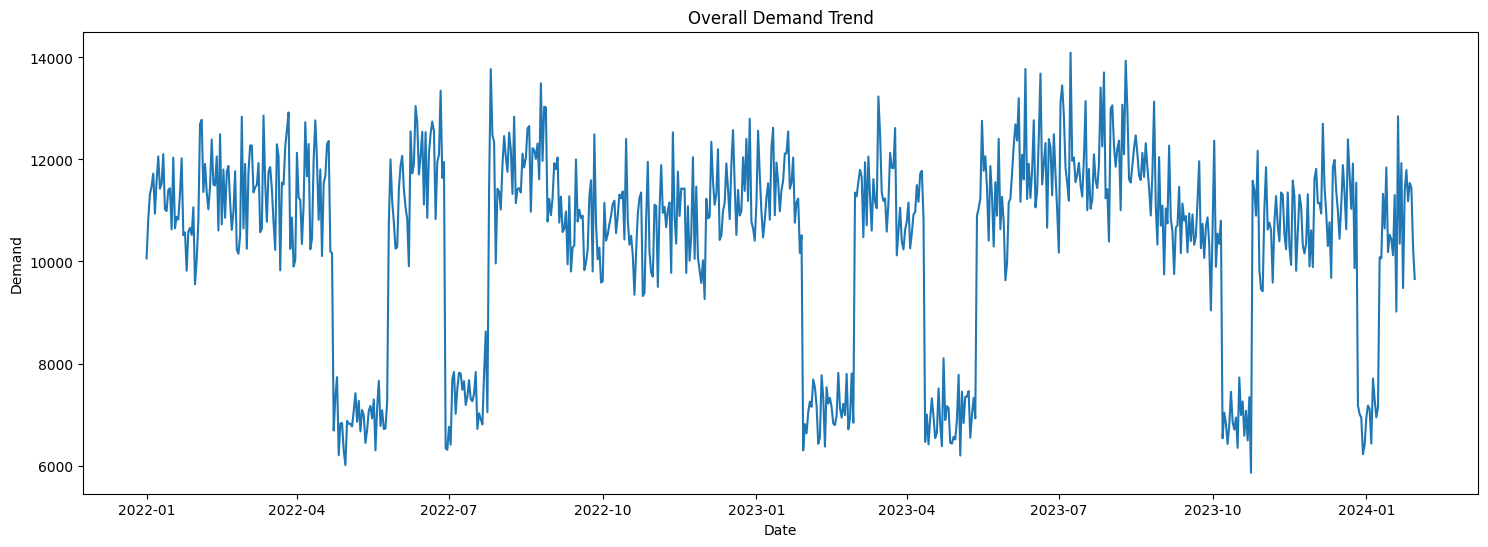

In [29]:
plt.figure(figsize=(18,6))

plt.plot(
    daily_demand["date"],
    daily_demand["demand"]
)

plt.title("Overall Demand Trend")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.show()

7 Day Moving Average

In [30]:
daily_demand["ma_7"] = (
    daily_demand["demand"]
    .rolling(window=7)
    .mean()
)

Trend with Moving Average

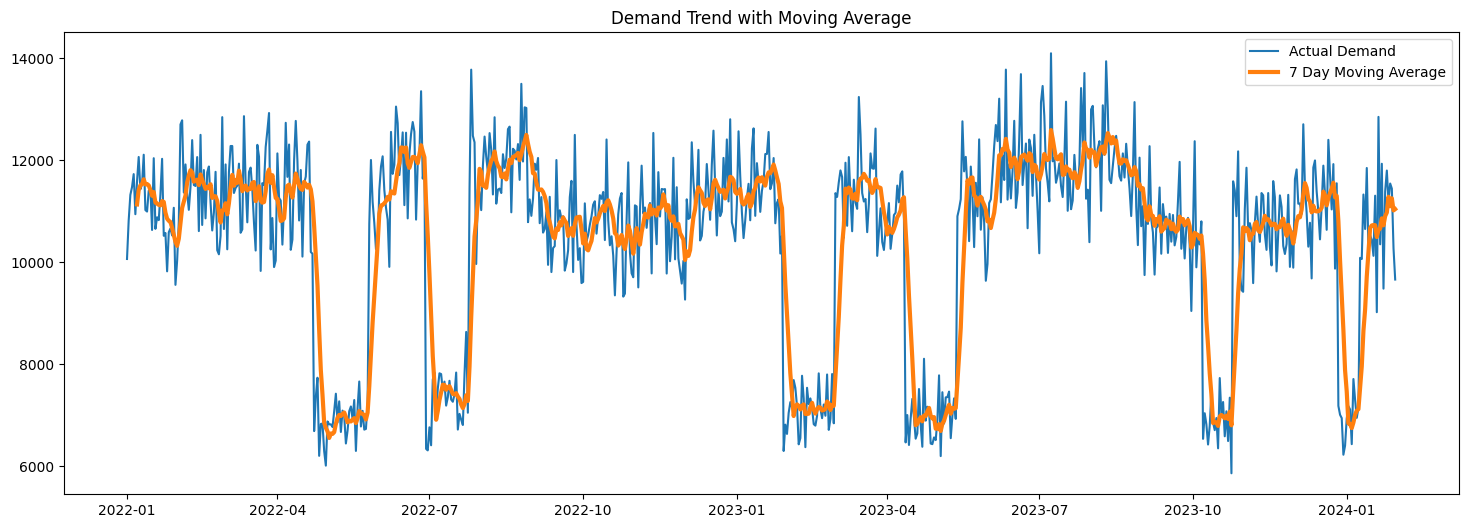

In [31]:
plt.figure(figsize=(18,6))

plt.plot(
    daily_demand["date"],
    daily_demand["demand"],
    label="Actual Demand"
)

plt.plot(
    daily_demand["date"],
    daily_demand["ma_7"],
    linewidth=3,
    label="7 Day Moving Average"
)

plt.legend()

plt.title("Demand Trend with Moving Average")

plt.show()

# Time Series Decomposition

Set Date Index

In [32]:
ts_data = daily_demand.copy()

ts_data = ts_data.set_index("date")

Seasonal Decomposition

In [33]:
decomposition = seasonal_decompose(
    ts_data["demand"],
    model="additive",
    period=30
)

Plot Decomposition

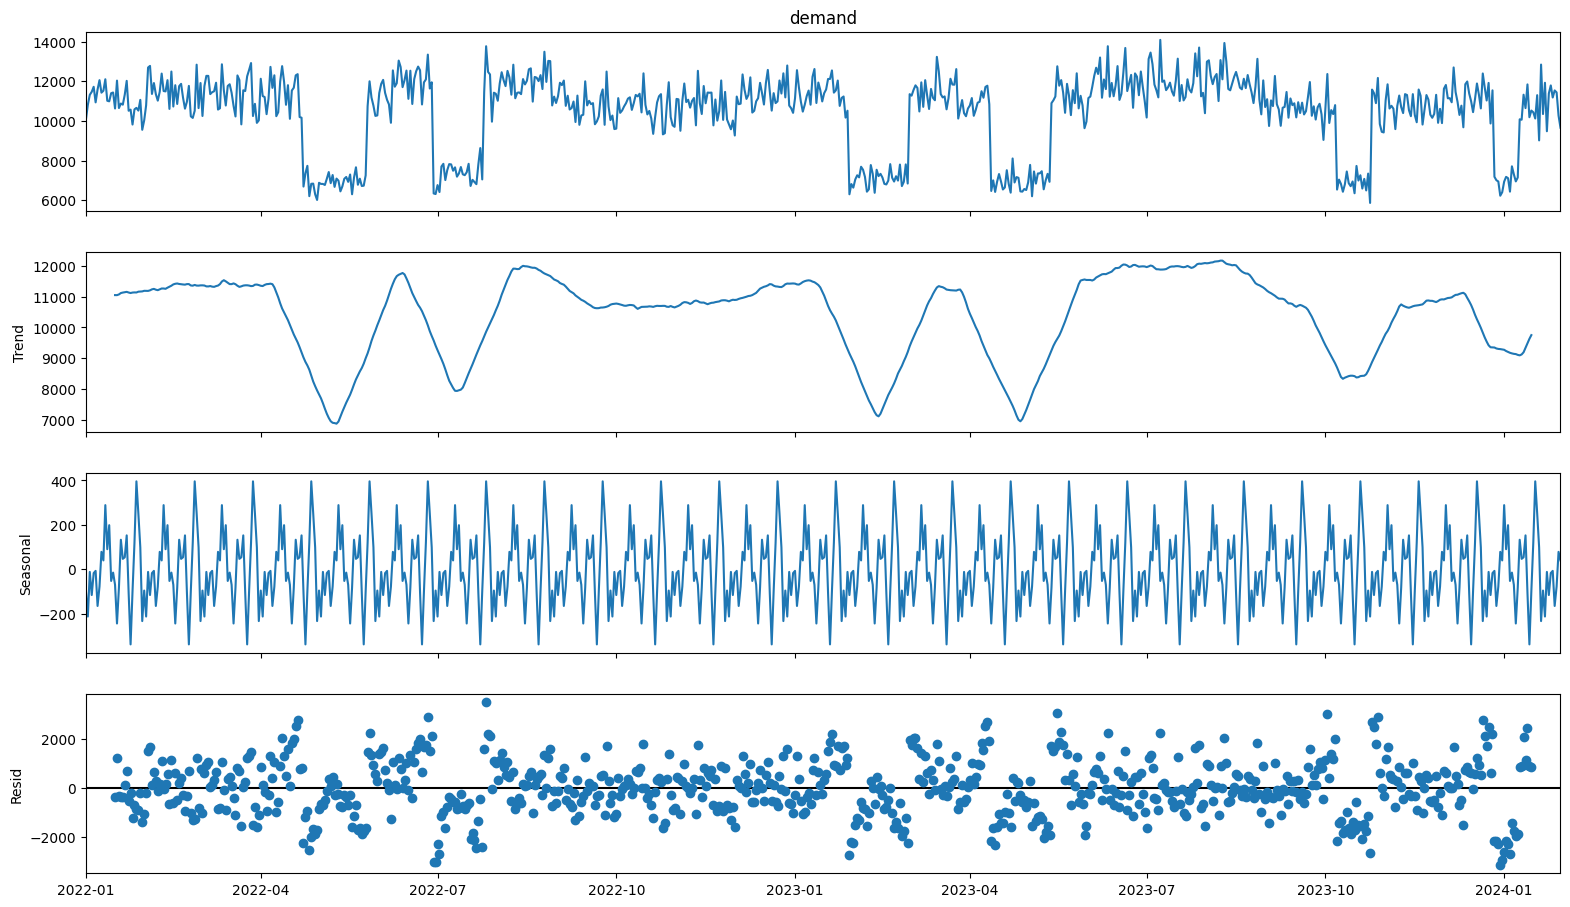

In [34]:
fig = decomposition.plot()

fig.set_size_inches(18,10)

plt.show()

# Monthly Demand Analysis

Extract Month

In [35]:
df["month"] = df["date"].dt.month

Monthly Demand

In [36]:
monthly_demand = (
    df.groupby("month")["demand"]
    .mean()
    .reset_index()
)

Monthly Demand Plot

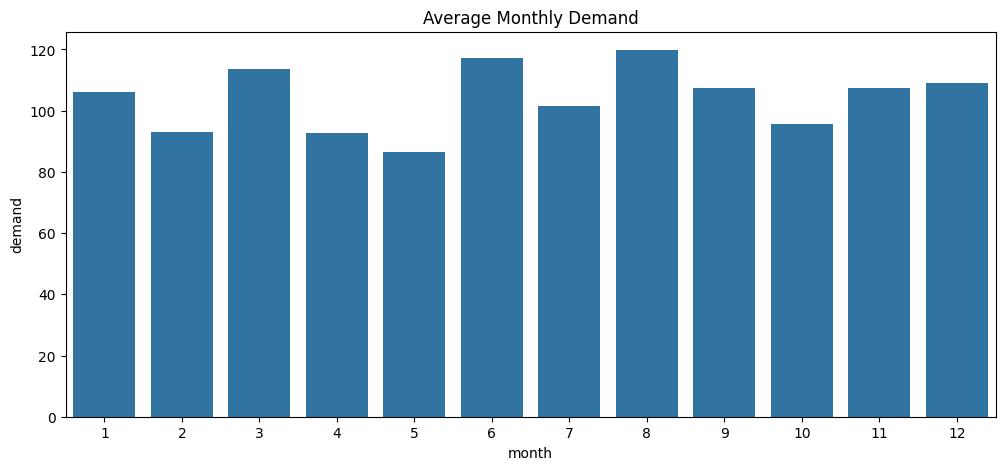

In [37]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=monthly_demand,
    x="month",
    y="demand"
)

plt.title("Average Monthly Demand")

plt.show()

# Day of Week Analysis

Day Name Feature

In [38]:
df["day_name"] = df["date"].dt.day_name()

Weekly Demand Pattern

In [39]:
weekly_pattern = (
    df.groupby("day_name")["demand"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

Weekly Pattern Plot

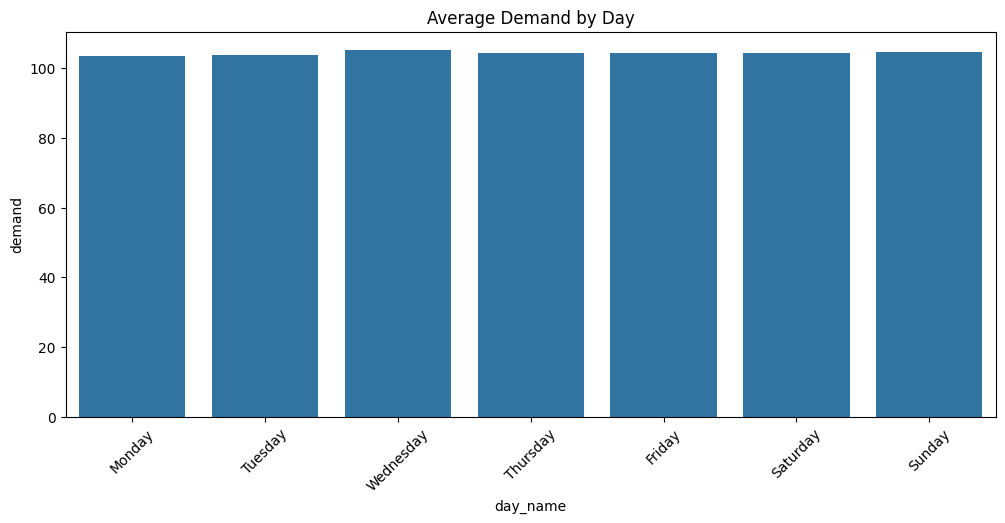

In [40]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=weekly_pattern,
    x="day_name",
    y="demand"
)

plt.title("Average Demand by Day")

plt.xticks(rotation=45)

plt.show()

# Product Wise Demand

Top Products

In [41]:
top_products = (
    df.groupby("product_id")["demand"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Top Product Plot

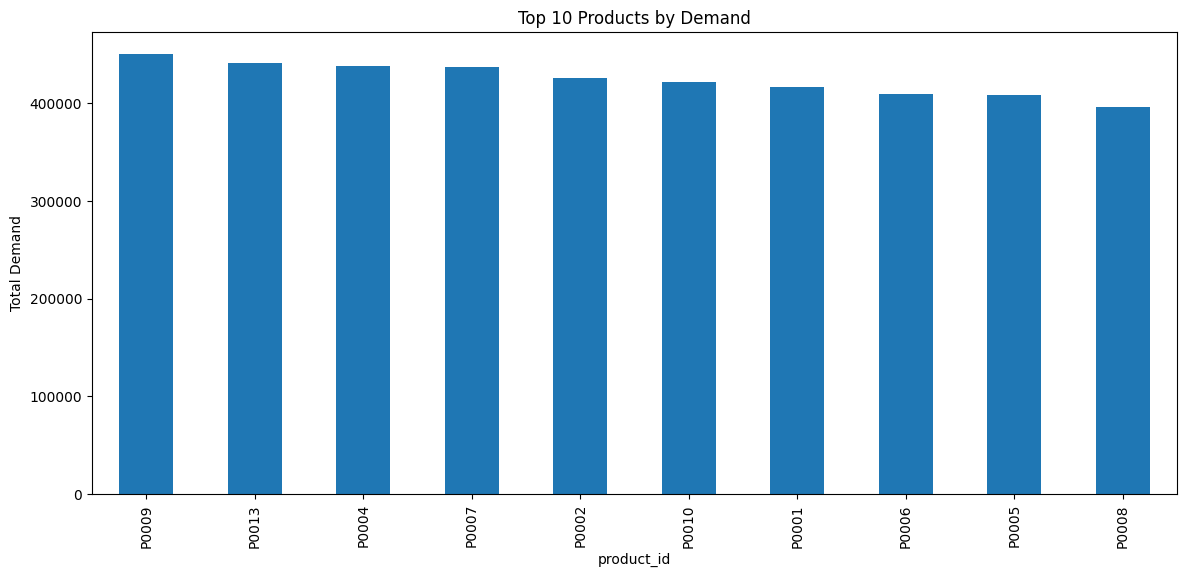

In [42]:
plt.figure(figsize=(14,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Demand")

plt.ylabel("Total Demand")

plt.show()

# Store Wise Demand

Store Demand

In [43]:
store_demand = (
    df.groupby("store_id")["demand"]
    .sum()
    .sort_values(ascending=False)
)

Store Demand Plot

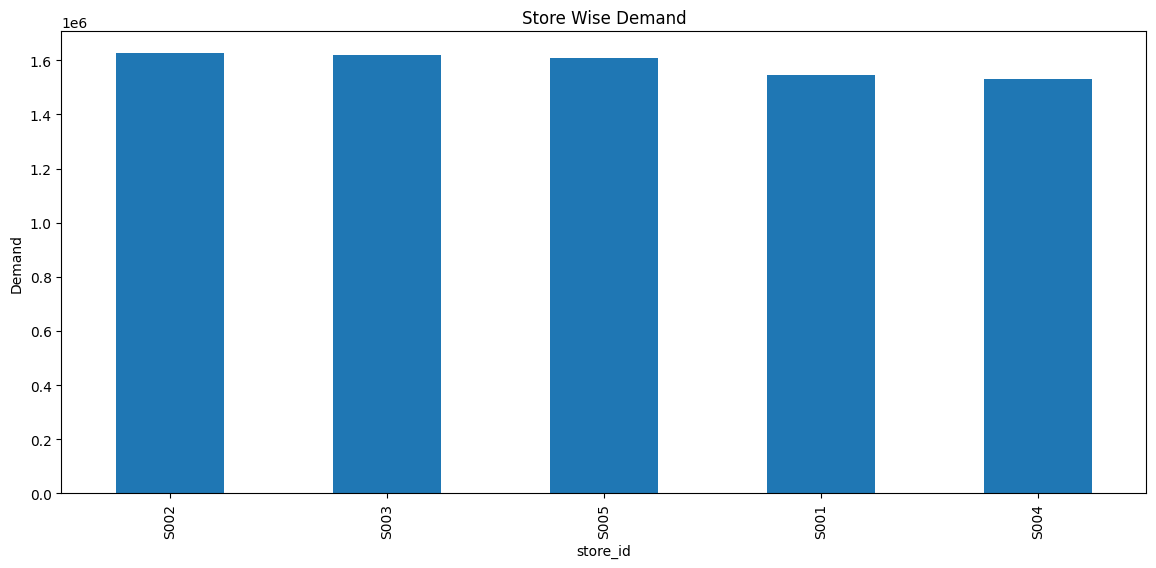

In [44]:
plt.figure(figsize=(14,6))

store_demand.plot(kind="bar")

plt.title("Store Wise Demand")

plt.ylabel("Demand")

plt.show()

# Category Analysis

Category Demand

In [45]:
category_demand = (
    df.groupby("category")["demand"]
    .mean()
    .sort_values(ascending=False)
)

Category Plot

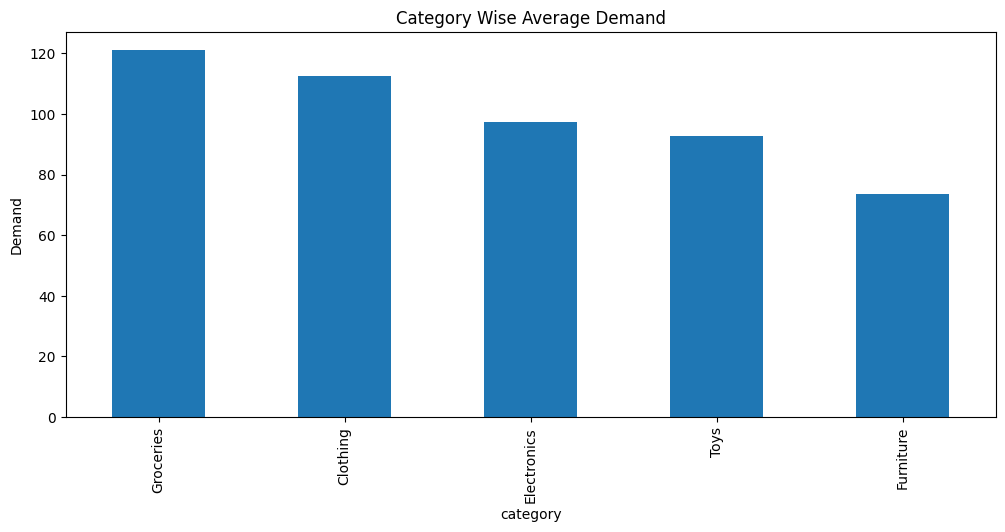

In [46]:
plt.figure(figsize=(12,5))

category_demand.plot(kind="bar")

plt.title("Category Wise Average Demand")

plt.ylabel("Demand")

plt.show()

# Promotion Impact

Promotion Analysis

In [47]:
promotion_analysis = (
    df.groupby("promotion")["demand"]
    .mean()
    .reset_index()
)

promotion_analysis

,promotion,demand
0,0,95.026843
1,1,123.269400


Promotion Plot

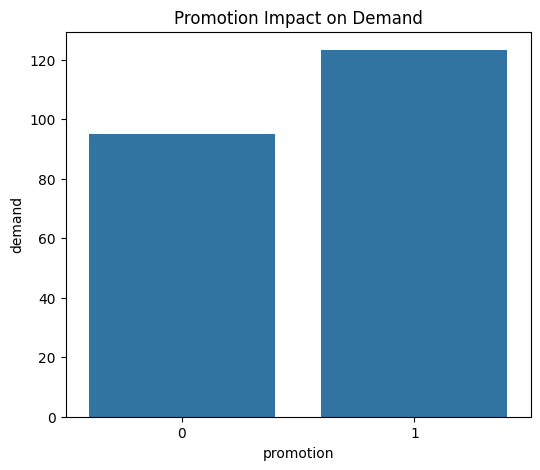

In [48]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=promotion_analysis,
    x="promotion",
    y="demand"
)

plt.title("Promotion Impact on Demand")

plt.show()

# Weather Impact

Weather Analysis

In [49]:
weather_analysis = (
    df.groupby("weather_condition")["demand"]
    .mean()
    .sort_values(ascending=False)
)

Weather Plot

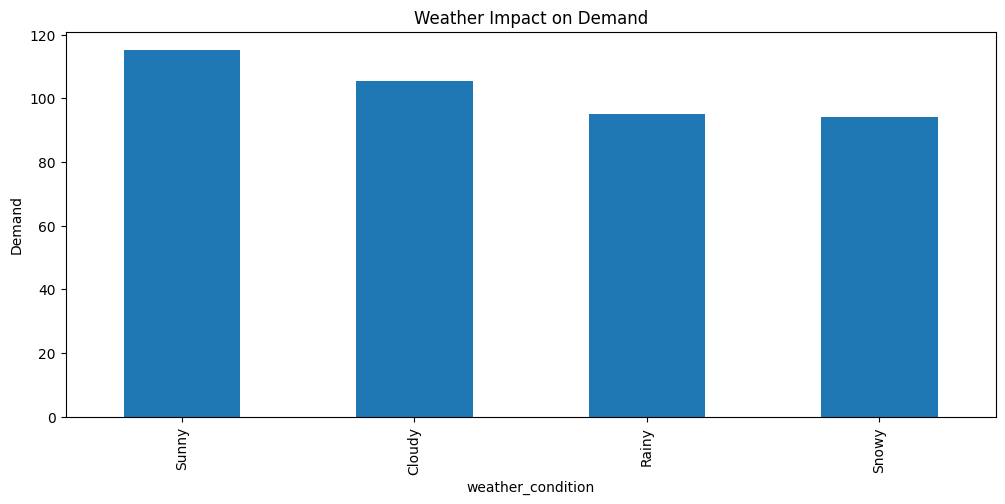

In [50]:
plt.figure(figsize=(12,5))

weather_analysis.plot(kind="bar")

plt.title("Weather Impact on Demand")

plt.ylabel("Demand")

plt.show()

# Epidemic Impact

Epidemic Analysis

In [51]:
epidemic_analysis = (
    df.groupby("epidemic")["demand"]
    .mean()
    .reset_index()
)

epidemic_analysis

,epidemic,demand
0,0,112.856743
1,1,70.158816


Epidemic Plot

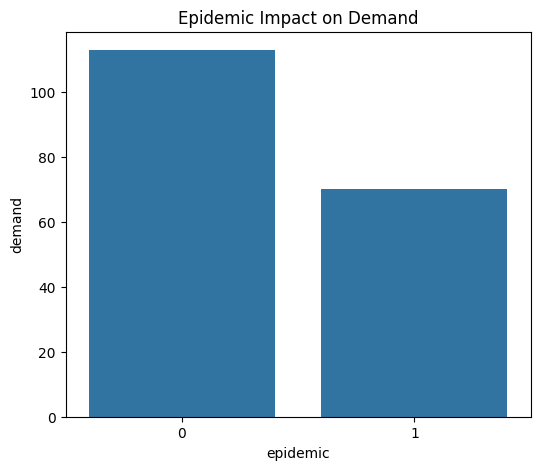

In [52]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=epidemic_analysis,
    x="epidemic",
    y="demand"
)

plt.title("Epidemic Impact on Demand")

plt.show()

# Correlation Analysis

Numeric Columns

In [53]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

Correlation Matrix

In [54]:
corr_matrix = df[numeric_cols].corr()

Heatmap

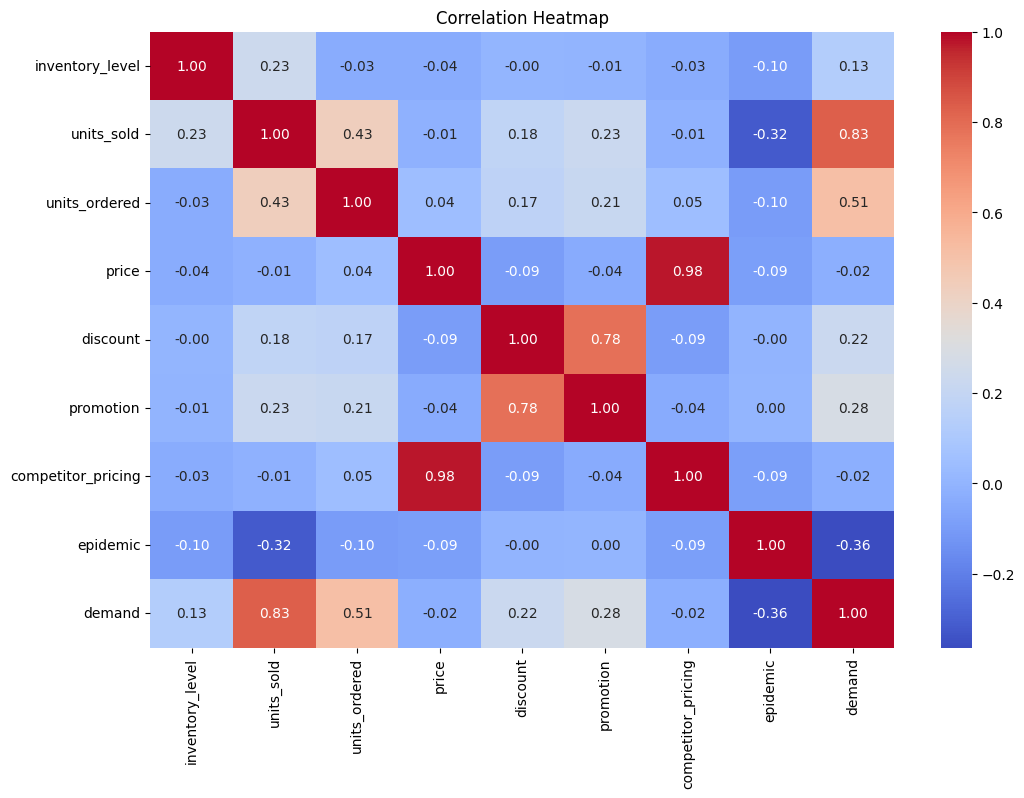

In [55]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Demand Distribution

Distribution Plot

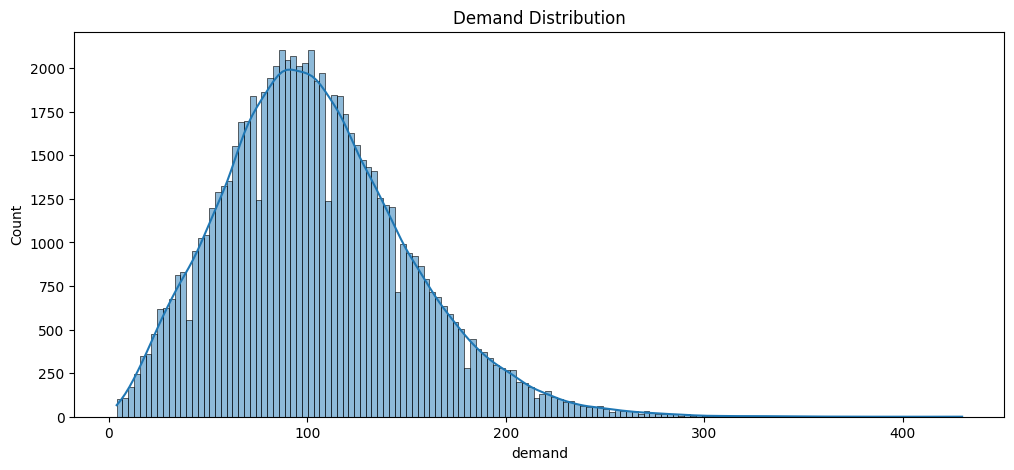

In [56]:
plt.figure(figsize=(12,5))

sns.histplot(
    df["demand"],
    kde=True
)

plt.title("Demand Distribution")

plt.show()

# Outlier Detection Visualization

Boxplot

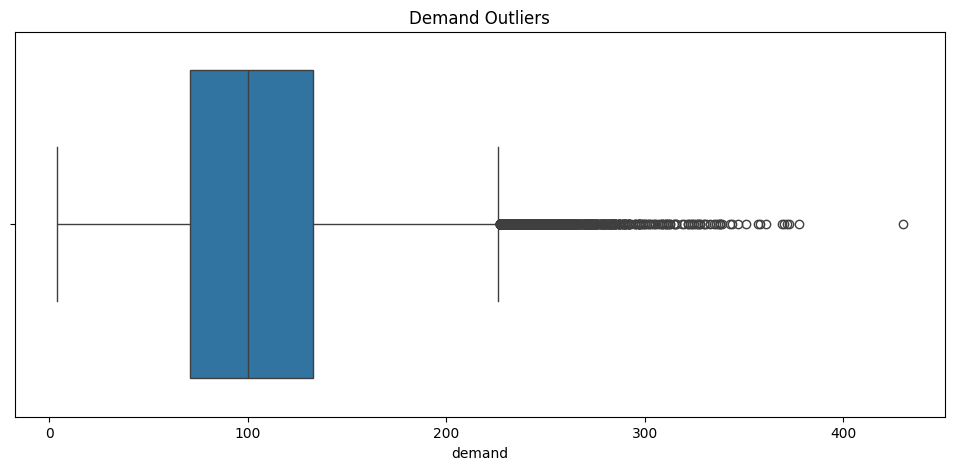

In [57]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df["demand"])

plt.title("Demand Outliers")

plt.show()

# Rolling Statistics

Rolling Mean & Std

In [58]:
daily_demand["rolling_mean_30"] = (
    daily_demand["demand"]
    .rolling(window=30)
    .mean()
)

daily_demand["rolling_std_30"] = (
    daily_demand["demand"]
    .rolling(window=30)
    .std()
)

Rolling Statistics Plot

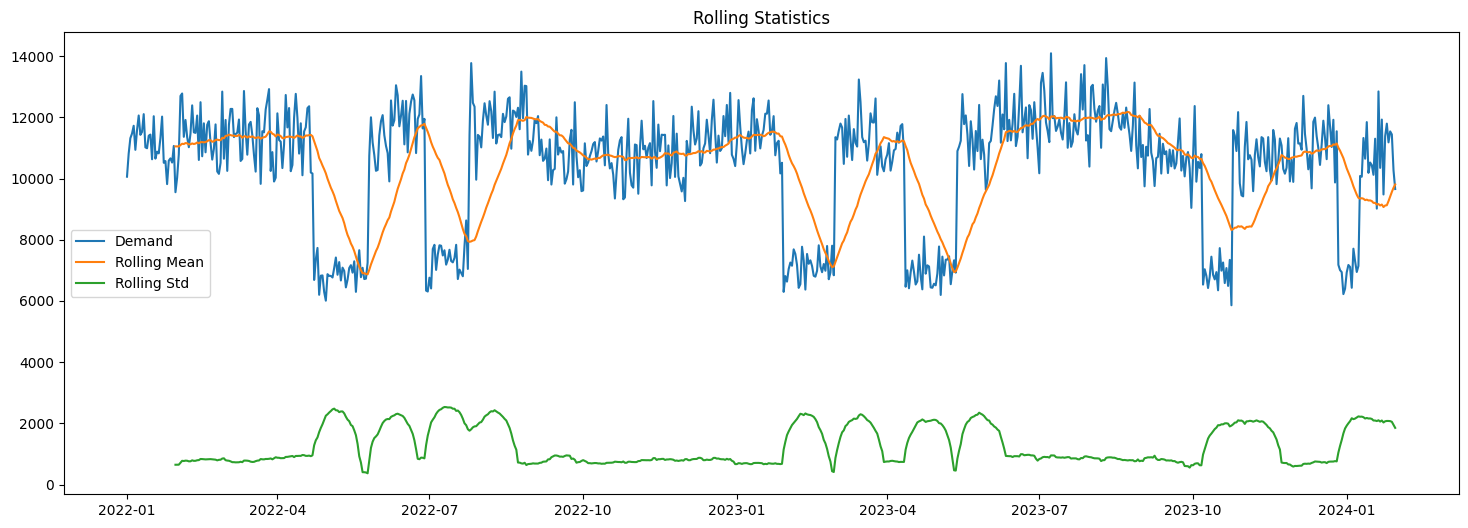

In [59]:
plt.figure(figsize=(18,6))

plt.plot(
    daily_demand["date"],
    daily_demand["demand"],
    label="Demand"
)

plt.plot(
    daily_demand["date"],
    daily_demand["rolling_mean_30"],
    label="Rolling Mean"
)

plt.plot(
    daily_demand["date"],
    daily_demand["rolling_std_30"],
    label="Rolling Std"
)

plt.legend()

plt.title("Rolling Statistics")

plt.show()

# Demand Spike Detection

Top Demand Days

In [60]:
top_spikes = (
    daily_demand
    .sort_values("demand", ascending=False)
    .head(10)
)

top_spikes

,date,demand,ma_7,rolling_mean_30,rolling_std_30
553,2023-07-08,14093,12587.857143,12027.366667,952.839730
586,2023-08-10,13936,12365.571429,12032.300000,871.042900
526,2023-06-11,13773,12415.285714,11516.833333,934.638122
206,2022-07-26,13772,8915.857143,7946.266667,1805.628746
573,2023-07-28,13706,12344.000000,11987.000000,914.573652
535,2023-06-20,13684,12050.714286,11650.400000,992.894362
236,2022-08-25,13494,12115.857143,11902.533333,692.747191
548,2023-07-03,13452,11894.142857,12032.933333,892.871576
571,2023-07-26,13411,11812.714286,11914.733333,867.144141
176,2022-06-26,13349,12291.142857,11732.500000,880.679900


# Pairplot Sample

Pairplot

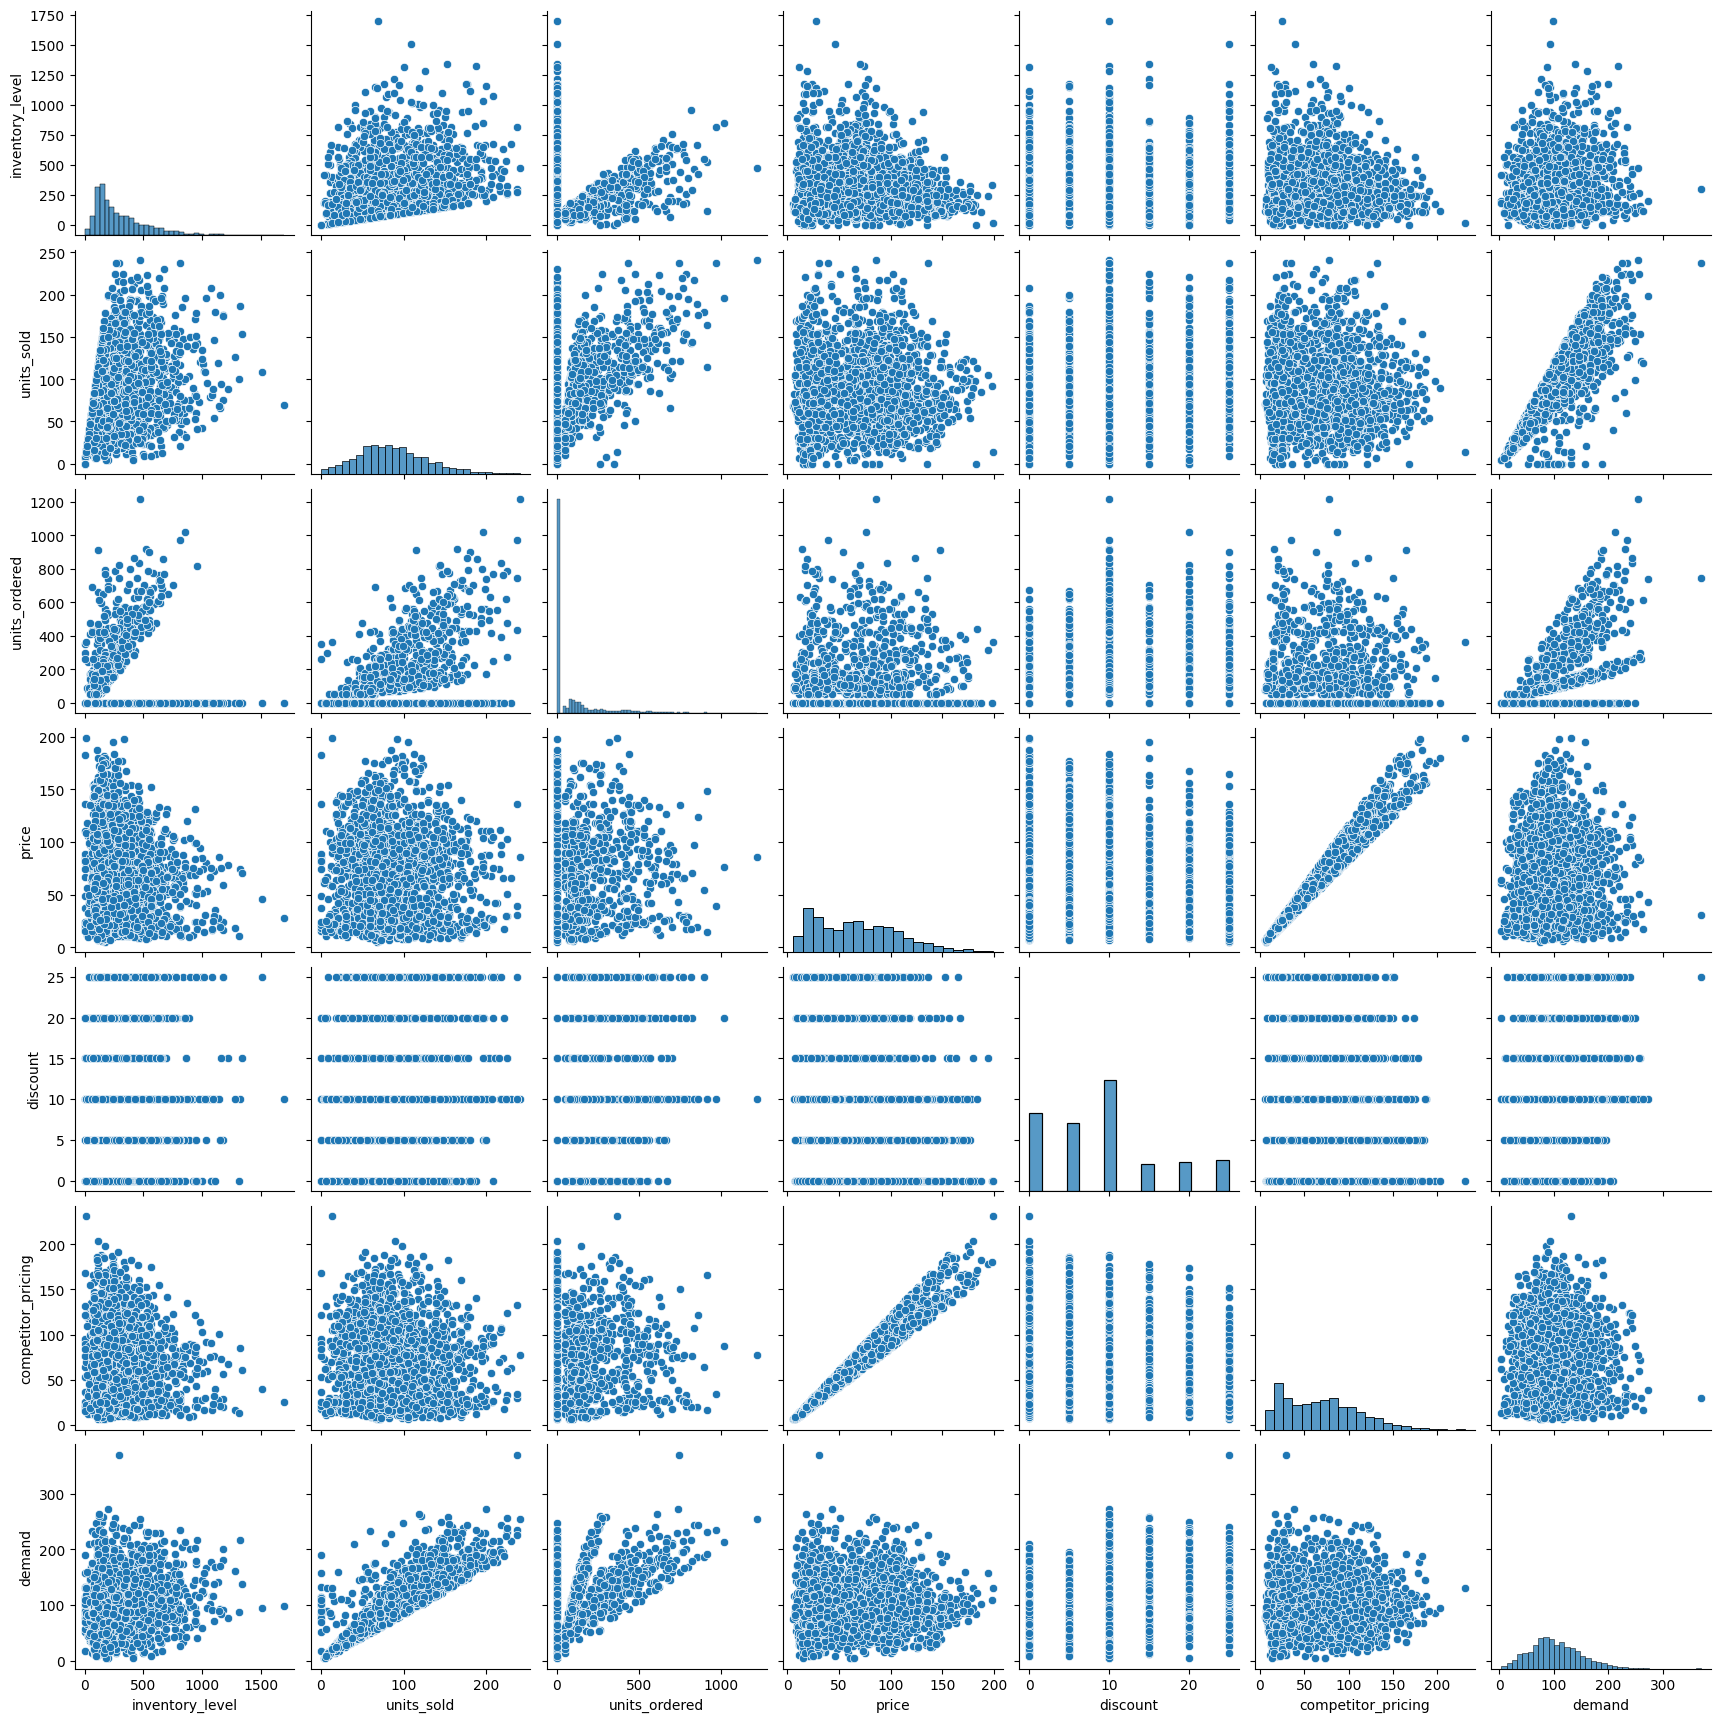

In [61]:
sample_df = df.sample(2000, random_state=42)

sns.pairplot(
    sample_df[
        [
            "inventory_level",
            "units_sold",
            "units_ordered",
            "price",
            "discount",
            "competitor_pricing",
            "demand"
        ]
    ]
)

plt.show()

# Feature Engineering

Date Features

In [62]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.dayofweek

df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

df["quarter"] = df["date"].dt.quarter

df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

Holiday Flag

In [63]:
df["is_holiday"] = (
    (df["promotion"] == 1) &
    (df["is_weekend"] == 1)
).astype(int)

# Cyclic Encoding

Month Cyclic Encoding

In [64]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)

df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

Day of Week Cyclic Encoding

In [65]:
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)

df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Lag Features

Sort Properly

In [66]:
df = df.sort_values(
    ["store_id", "product_id", "date"]
)

Lag Features

In [67]:
df["demand_lag_1"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .shift(1)
)

df["demand_lag_7"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .shift(7)
)

df["demand_lag_14"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .shift(14)
)

df["demand_lag_30"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .shift(30)
)

# Rolling Features

Rolling Mean Features

In [68]:
df["rolling_mean_7"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

df["rolling_mean_14"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

df["rolling_mean_30"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

Rolling Std Features

In [69]:
df["rolling_std_7"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)

df["rolling_std_30"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .transform(
        lambda x: x.shift(1).rolling(30).std()
    )
)

# Expanding Statistics

Expanding Mean

In [70]:
df["expanding_mean"] = (
    df.groupby(
        ["store_id", "product_id"]
    )["demand"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

# Demand Change

In [71]:
df["demand_change_1"] = (
    df["demand"] -
    df["demand_lag_1"]
)

df["demand_change_7"] = (
    df["demand"] -
    df["demand_lag_7"]
)

# Price Related

Price Difference

In [72]:
df["price_diff"] = (
    df["price"] -
    df["competitor_pricing"]
)

Discounted Price

In [73]:
df["discounted_price"] = (
    df["price"] *
    (1 - df["discount"] / 100)
)

# Inventory Features

Inventory Ratio

In [74]:
df["inventory_sales_ratio"] = (
    df["inventory_level"] /
    (df["units_sold"] + 1)
)

# Encode Categorical Features

Label Encoding

In [75]:
from sklearn.preprocessing import LabelEncoder

Categorical Columns

In [76]:
categorical_cols = [
    "store_id",
    "product_id",
    "category",
    "region",
    "weather_condition",
    "seasonality"
]

Apply Encoding

In [77]:
label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

In [78]:
le_day = LabelEncoder()

df["day_name"] = le_day.fit_transform(
    df["day_name"]
)

# Missing Values from Lag Features

Missing Check

In [79]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
rolling_std_30,3000
rolling_mean_30,3000
demand_lag_30,3000
demand_lag_14,1400
rolling_mean_14,1400
rolling_std_7,700
rolling_mean_7,700
demand_lag_7,700
demand_change_7,700
demand_change_1,100


Remove Lag NaN Rows

In [80]:
df = df.dropna()

In [81]:
print(df.shape)

(73000, 44)


# Feature List

Feature Columns

In [82]:
feature_cols = [
    col for col in df.columns
    if col not in ["date", "demand"]
]

feature_cols

['store_id',
 'product_id',
 'category',
 'region',
 'inventory_level',
 'units_sold',
 'units_ordered',
 'price',
 'discount',
 'weather_condition',
 'promotion',
 'competitor_pricing',
 'seasonality',
 'epidemic',
 'month',
 'day_name',
 'year',
 'day',
 'day_of_week',
 'week_of_year',
 'quarter',
 'is_weekend',
 'is_holiday',
 'month_sin',
 'month_cos',
 'dow_sin',
 'dow_cos',
 'demand_lag_1',
 'demand_lag_7',
 'demand_lag_14',
 'demand_lag_30',
 'rolling_mean_7',
 'rolling_mean_14',
 'rolling_mean_30',
 'rolling_std_7',
 'rolling_std_30',
 'expanding_mean',
 'demand_change_1',
 'demand_change_7',
 'price_diff',
 'discounted_price',
 'inventory_sales_ratio']

# Train Test Split

Chronological Split

In [83]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]

test_df = df.iloc[split_index:]

X and y

In [84]:
X_train = train_df[feature_cols]

y_train = train_df["demand"]

X_test = test_df[feature_cols]

y_test = test_df["demand"]

In [85]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(58400, 42)
(14600, 42)
(58400,)
(14600,)


# Baseline Forecasting + TimeSeriesSplit Validation

Import Libraries

In [86]:
from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Evaluation Function

Metrics Function

In [87]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.4f}%")

    return mae, rmse, mape

# Previous Day Forecast

Naive Prediction

In [88]:
naive_pred = test_df["demand_lag_1"]

Naive Evaluation

In [89]:
print("Naive Forecast Performance\n")

naive_mae, naive_rmse, naive_mape = evaluate_model(
    y_test,
    naive_pred
)

Naive Forecast Performance

MAE  : 41.6108
RMSE : 54.3770
MAPE : 50.6203%


# Rolling Mean Forecast

Rolling Mean Prediction

In [90]:
rolling_pred = test_df["rolling_mean_7"]

Rolling Mean Evaluation

In [91]:
print("Rolling Mean Forecast Performance\n")

rolling_mae, rolling_rmse, rolling_mape = evaluate_model(
    y_test,
    rolling_pred
)

Rolling Mean Forecast Performance

MAE  : 32.7149
RMSE : 42.5372
MAPE : 43.4522%


# Compare Baselines

Baseline Comparison

In [92]:
baseline_results = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Rolling Mean Forecast"
    ],

    "MAE": [
        naive_mae,
        rolling_mae
    ],

    "RMSE": [
        naive_rmse,
        rolling_rmse
    ],

    "MAPE": [
        naive_mape,
        rolling_mape
    ]
})

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Forecast,41.610822,54.376979,50.620263
1,Rolling Mean Forecast,32.714883,42.537245,43.452214


# Visual Comparison

Actual vs Naive

In [93]:
plot_df = pd.DataFrame({
    "Actual": y_test.values,
    "Naive_Prediction": naive_pred.values
})

plot_df = plot_df.head(200)

Plot

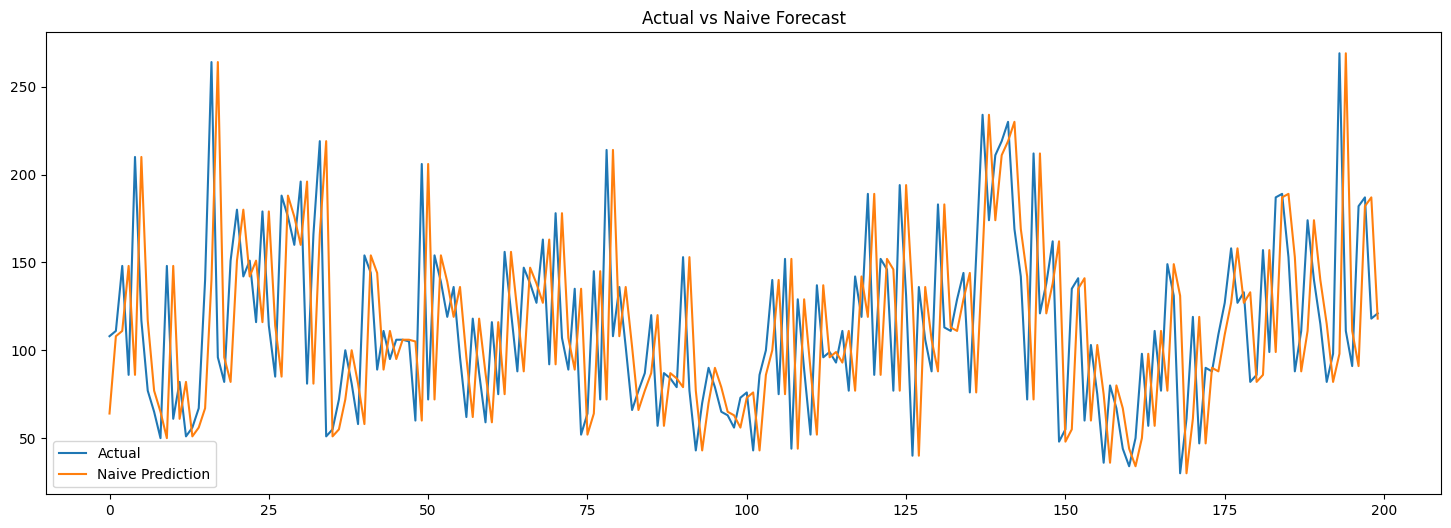

In [94]:
plt.figure(figsize=(18,6))

plt.plot(
    plot_df["Actual"],
    label="Actual"
)

plt.plot(
    plot_df["Naive_Prediction"],
    label="Naive Prediction"
)

plt.legend()

plt.title("Actual vs Naive Forecast")

plt.show()

# TimeSeriesSplit Validation

Create Splitter

In [95]:
tscv = TimeSeriesSplit(n_splits=5)

Visualize Splits

In [96]:
for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_train)
):

    print(f"\nFold {fold+1}")

    print("Train Size:", len(train_idx))
    print("Validation Size:", len(val_idx))


Fold 1
Train Size: 9735
Validation Size: 9733

Fold 2
Train Size: 19468
Validation Size: 9733

Fold 3
Train Size: 29201
Validation Size: 9733

Fold 4
Train Size: 38934
Validation Size: 9733

Fold 5
Train Size: 48667
Validation Size: 9733


# Baseline CV Evaluation

Cross Validation Loop

In [97]:
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_train)
):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]


    val_pred = X_val["rolling_mean_7"]


    mae = mean_absolute_error(
        y_val,
        val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_val,
        val_pred
    ) * 100


    cv_scores.append([
        fold + 1,
        mae,
        rmse,
        mape
    ])

CV Results

In [98]:
cv_results = pd.DataFrame(
    cv_scores,
    columns=[
        "Fold",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

cv_results

,Fold,MAE,RMSE,MAPE
0,1,32.461934,42.053421,46.481682
1,2,32.450544,41.688740,42.846548
2,3,33.152530,43.215603,42.913912
3,4,33.070364,42.895424,42.293487
4,5,29.357605,37.797583,44.071057


Average CV Score

In [99]:
print("Average CV Metrics\n")

print(
    cv_results[
        ["MAE", "RMSE", "MAPE"]
    ].mean()
)

Average CV Metrics

MAE     32.098595
RMSE    41.530154
MAPE    43.721337
dtype: float64


# Residual Analysis

Residual Calculation

In [100]:
baseline_residuals = (
    y_test -
    rolling_pred
)

Residual Distribution

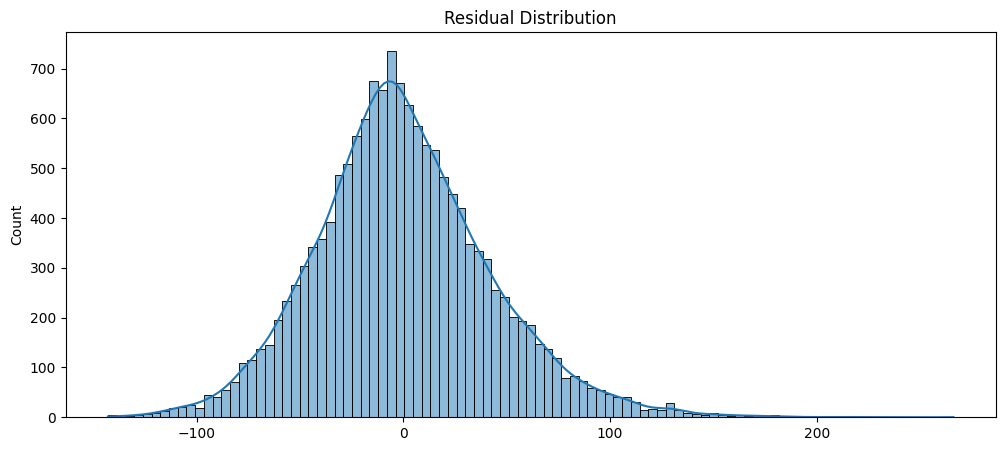

In [101]:
plt.figure(figsize=(12,5))

sns.histplot(
    baseline_residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

Residual Time Plot

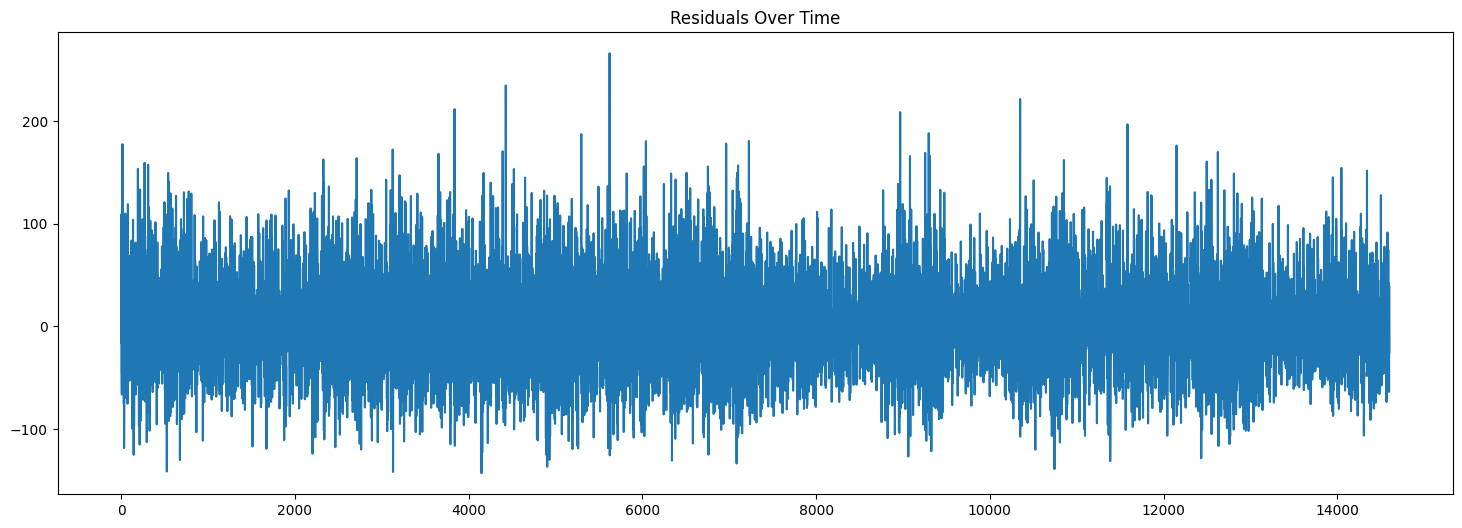

In [102]:
plt.figure(figsize=(18,6))

plt.plot(
    baseline_residuals.values
)

plt.title("Residuals Over Time")

plt.show()

In [103]:
feature_cols = [
    col for col in df.columns
    if col not in ["date", "demand"]
]

# CatBoost Regressor Training

Import CatBoost

In [104]:
from catboost import CatBoostRegressor

Initial CatBoost Model

In [105]:
cat_model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

Train Model

In [106]:
X_train = train_df[feature_cols]

y_train = train_df["demand"]

X_test = test_df[feature_cols]

y_test = test_df["demand"]

In [107]:
cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 45.6063778	test: 47.4041856	best: 47.4041856 (0)	total: 103ms	remaining: 1m 42s
100:	learn: 8.2471448	test: 8.7570439	best: 8.7570439 (100)	total: 6.65s	remaining: 59.2s
200:	learn: 4.9525569	test: 5.2798764	best: 5.2798764 (200)	total: 10.5s	remaining: 41.7s
300:	learn: 3.6899246	test: 4.0277562	best: 4.0277562 (300)	total: 14.3s	remaining: 33.3s
400:	learn: 2.9212097	test: 3.2911411	best: 3.2911411 (400)	total: 19.6s	remaining: 29.2s
500:	learn: 2.3939556	test: 2.7939469	best: 2.7939469 (500)	total: 24.5s	remaining: 24.4s
600:	learn: 2.0218826	test: 2.4541612	best: 2.4541612 (600)	total: 28.3s	remaining: 18.8s
700:	learn: 1.7473015	test: 2.2095502	best: 2.2095502 (700)	total: 32.2s	remaining: 13.7s
800:	learn: 1.5460552	test: 2.0435351	best: 2.0435351 (800)	total: 39.7s	remaining: 9.86s
900:	learn: 1.3923811	test: 1.9195229	best: 1.9195229 (900)	total: 44.6s	remaining: 4.91s
999:	learn: 1.2688123	test: 1.8207467	best: 1.8207467 (999)	total: 48.9s	remaining: 0us

bestTest = 

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

Predict

In [108]:
cat_pred = cat_model.predict(X_test)

Evaluate CatBoost

In [109]:
print("CatBoost Performance\n")

cat_mae, cat_rmse, cat_mape = evaluate_model(
    y_test,
    cat_pred
)

CatBoost Performance

MAE  : 1.0565
RMSE : 1.8207
MAPE : 1.4115%


# Actual vs Prediction

Create Plot Data

In [110]:
cat_plot_df = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": cat_pred
})

cat_plot_df = cat_plot_df.head(300)

Plot Predictions

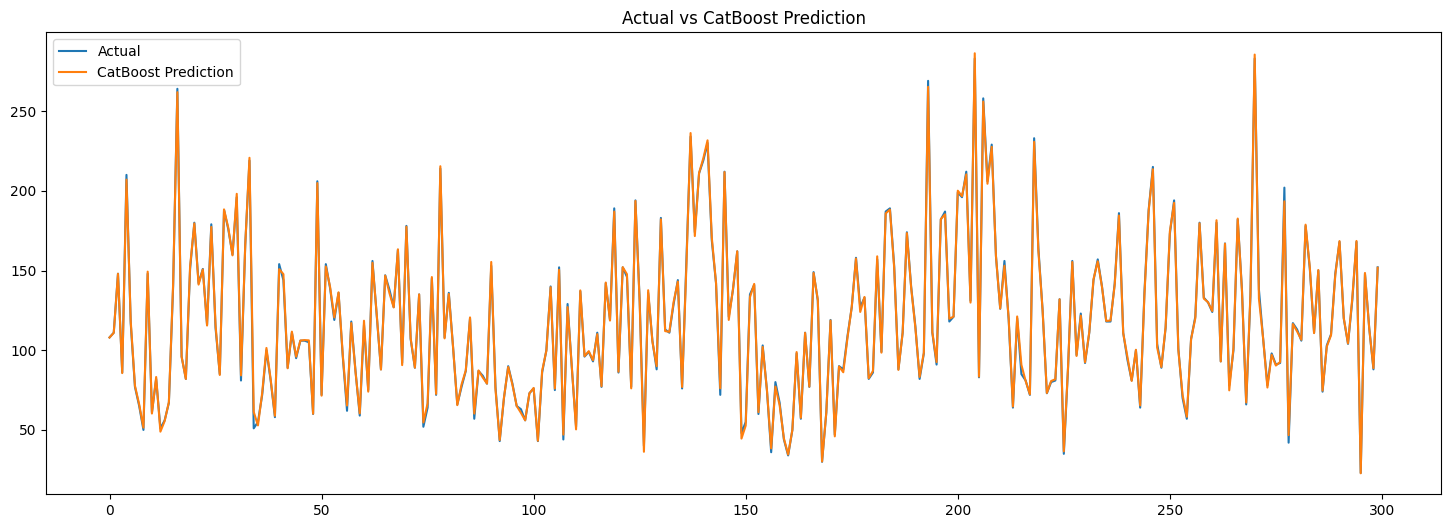

In [111]:
plt.figure(figsize=(18,6))

plt.plot(
    cat_plot_df["Actual"],
    label="Actual"
)

plt.plot(
    cat_plot_df["Prediction"],
    label="CatBoost Prediction"
)

plt.legend()

plt.title("Actual vs CatBoost Prediction")

plt.show()

# Feature Importance

In [112]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
38,demand_change_7,22.609334
37,demand_change_1,20.695405
5,units_sold,20.299364
27,demand_lag_1,15.970301
28,demand_lag_7,15.725482
41,inventory_sales_ratio,2.171101
31,rolling_mean_7,1.263605
6,units_ordered,0.863804
32,rolling_mean_14,0.235281
4,inventory_level,0.100924


Plot Feature Importance

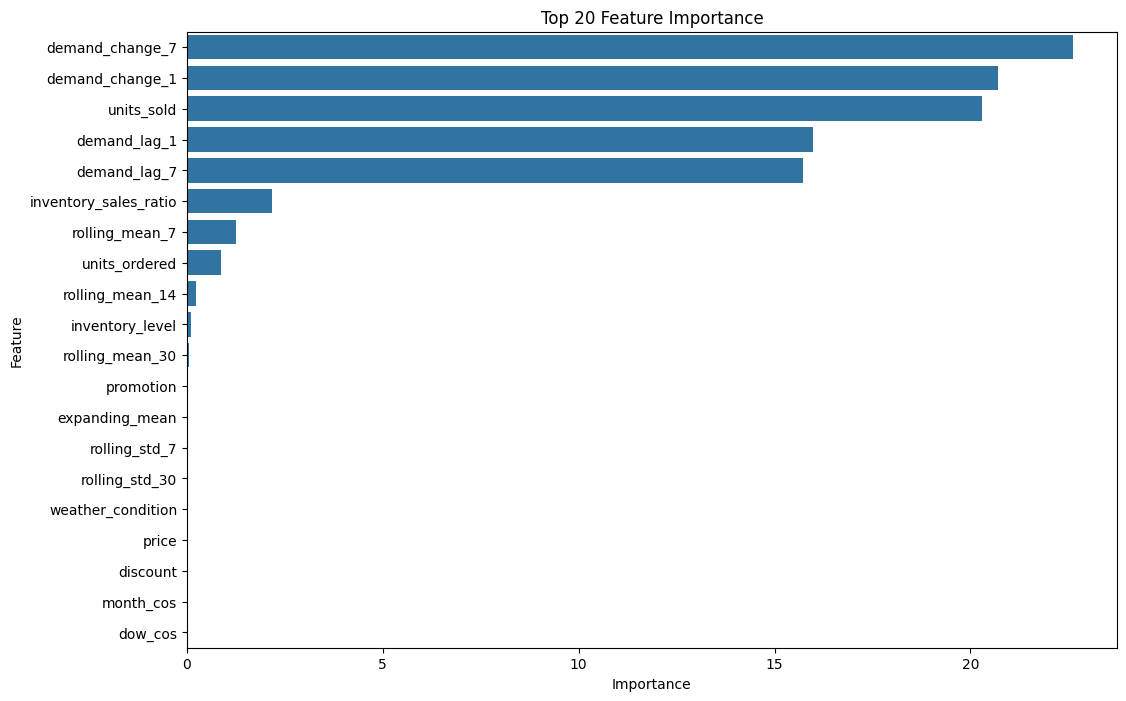

In [113]:
top_features = feature_importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance")

plt.show()

# Residual Analysis

Residuals

In [114]:
cat_residuals = (
    y_test -
    cat_pred
)

Residual Distribution

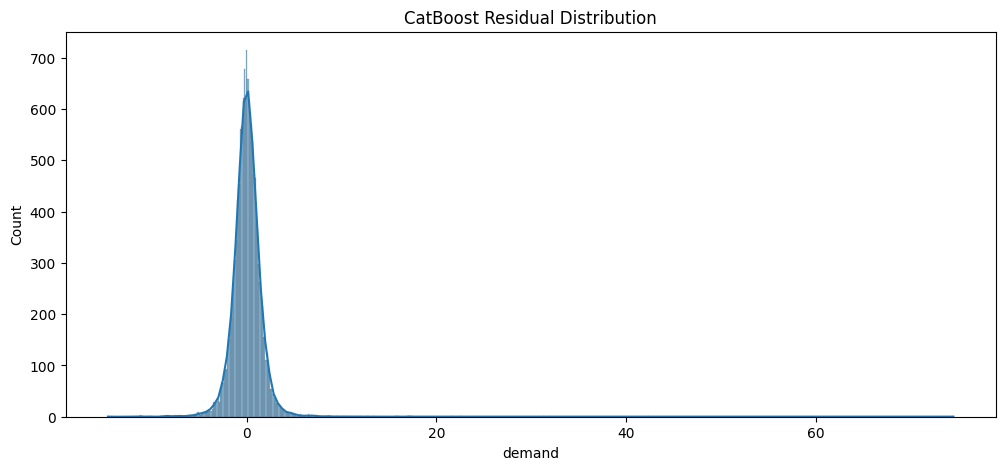

In [115]:
plt.figure(figsize=(12,5))

sns.histplot(
    cat_residuals,
    kde=True
)

plt.title("CatBoost Residual Distribution")

plt.show()

Residual Plot

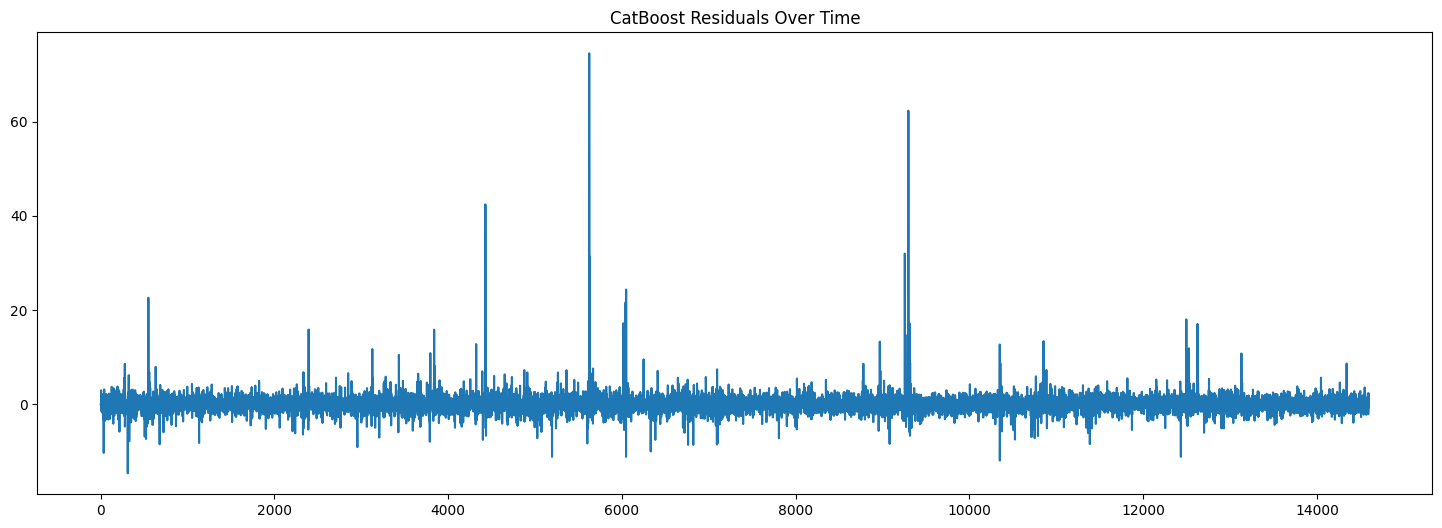

In [116]:
plt.figure(figsize=(18,6))

plt.plot(cat_residuals.values)

plt.title("CatBoost Residuals Over Time")

plt.show()

# Overfitting Check

Train Prediction

In [117]:
train_pred = cat_model.predict(X_train)

Train Metrics

In [118]:
print("Train Performance\n")

train_mae, train_rmse, train_mape = evaluate_model(
    y_train,
    train_pred
)

Train Performance

MAE  : 0.9354
RMSE : 1.2688
MAPE : 1.3121%


Test Metrics

In [119]:
print("Test Performance\n")

test_mae, test_rmse, test_mape = evaluate_model(
    y_test,
    cat_pred
)

Test Performance

MAE  : 1.0565
RMSE : 1.8207
MAPE : 1.4115%


# TimeSeriesSplit Cross Validation

CV Training

In [120]:
cat_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_train)
):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]


    model = CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0,
        random_seed=42
    )


    model.fit(X_tr, y_tr)


    val_pred = model.predict(X_val)


    mae = mean_absolute_error(
        y_val,
        val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_val,
        val_pred
    ) * 100


    cat_cv_scores.append([
        fold + 1,
        mae,
        rmse,
        mape
    ])

CV Results

In [121]:
cat_cv_results = pd.DataFrame(
    cat_cv_scores,
    columns=[
        "Fold",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

cat_cv_results

,Fold,MAE,RMSE,MAPE
0,1,2.205582,3.435402,3.102125
1,2,2.037550,2.760063,2.634583
2,3,1.824295,2.527641,2.335336
3,4,1.785429,2.515718,2.272829
4,5,1.656522,2.246097,2.547202


Average CV Metrics

In [122]:
print("Average CatBoost CV Metrics\n")

print(
    cat_cv_results[
        ["MAE", "RMSE", "MAPE"]
    ].mean()
)

Average CatBoost CV Metrics

MAE     1.901876
RMSE    2.696984
MAPE    2.578415
dtype: float64


# Compare with Baseline

Comparison Table

In [123]:
comparison_df = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Rolling Mean",
        "CatBoost"
    ],

    "MAE": [
        naive_mae,
        rolling_mae,
        cat_mae
    ],

    "RMSE": [
        naive_rmse,
        rolling_rmse,
        cat_rmse
    ],

    "MAPE": [
        naive_mape,
        rolling_mape,
        cat_mape
    ]
})

comparison_df

,Model,MAE,RMSE,MAPE
0,Naive Forecast,41.610822,54.376979,50.620263
1,Rolling Mean,32.714883,42.537245,43.452214
2,CatBoost,1.056456,1.820747,1.411490


# LightGBM + Weighted Ensemble Forecasting

Import LightGBM

In [124]:
from lightgbm import LGBMRegressor

Initialize Model

In [125]:
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

Train LightGBM

In [126]:
lgb_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060805 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5312
[LightGBM] [Info] Number of data points in the train set: 58400, number of used features: 42
[LightGBM] [Info] Start training from score 103.677551


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=8,
              n_estimators=1000, random_state=42, subsample=0.8)

Prediction

In [127]:
lgb_pred = lgb_model.predict(X_test)

Evaluation

In [128]:
print("LightGBM Performance\n")

lgb_mae, lgb_rmse, lgb_mape = evaluate_model(
    y_test,
    lgb_pred
)

LightGBM Performance

MAE  : 1.5358
RMSE : 2.3107
MAPE : 1.9124%


Visualization

Plot Data

In [129]:
lgb_plot_df = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": lgb_pred
})

lgb_plot_df = lgb_plot_df.head(300)


Plot Predictions

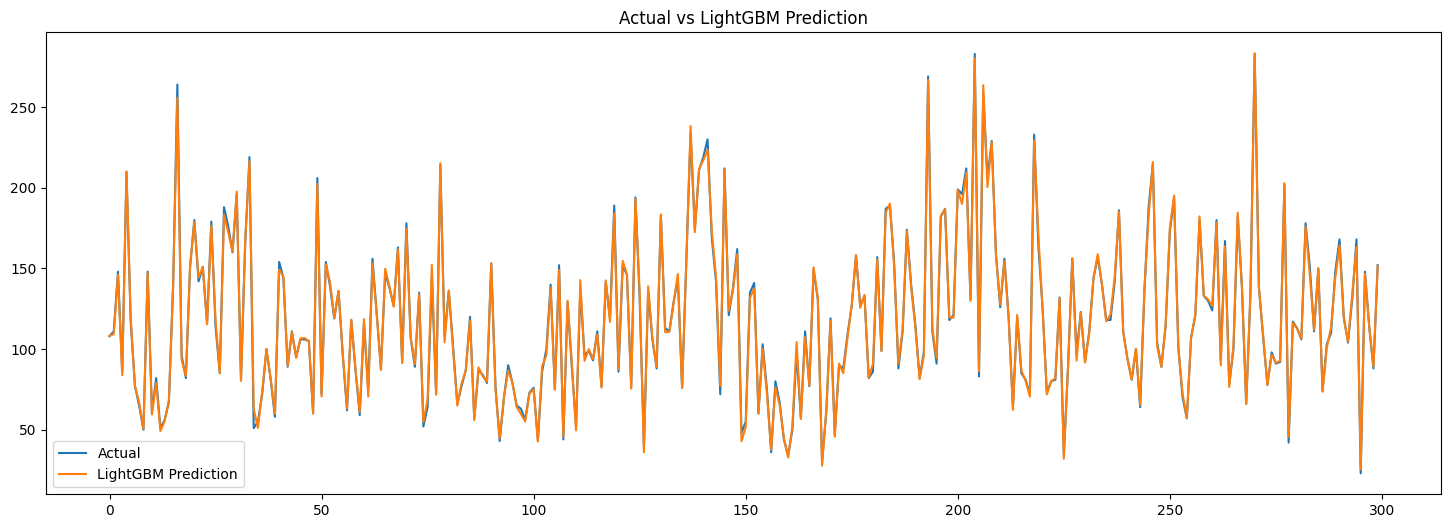

In [130]:
plt.figure(figsize=(18,6))

plt.plot(
    lgb_plot_df["Actual"],
    label="Actual"
)

plt.plot(
    lgb_plot_df["Prediction"],
    label="LightGBM Prediction"
)

plt.legend()

plt.title("Actual vs LightGBM Prediction")

plt.show()

# Feature Importance

Importance DataFrame

In [131]:
lgb_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": lgb_model.feature_importances_
})

lgb_importance = lgb_importance.sort_values(
    by="Importance",
    ascending=False
)

lgb_importance.head(20)

,Feature,Importance
5,units_sold,6190
37,demand_change_1,4841
38,demand_change_7,4646
27,demand_lag_1,4486
28,demand_lag_7,4433
41,inventory_sales_ratio,1440
6,units_ordered,1026
31,rolling_mean_7,916
4,inventory_level,805
32,rolling_mean_14,229


Plot Importance

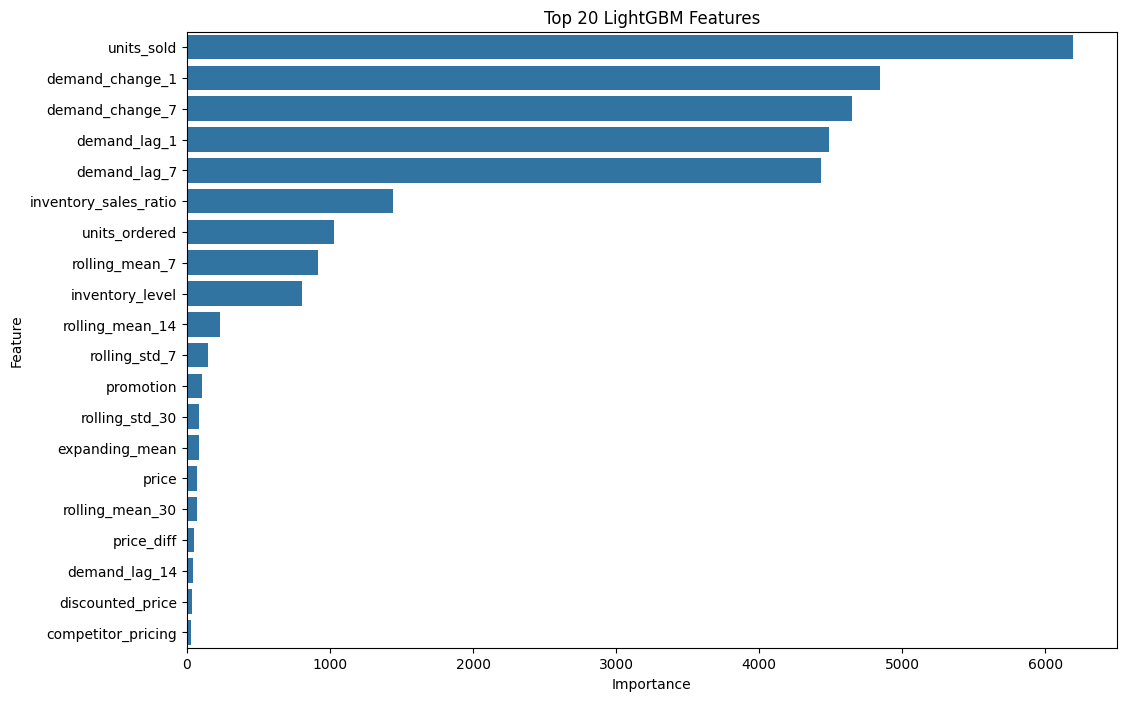

In [132]:
top_lgb_features = lgb_importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_lgb_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 LightGBM Features")

plt.show()

# Residual Analysis

Residuals

In [133]:
lgb_residuals = (
    y_test -
    lgb_pred
)

Residual Distribution

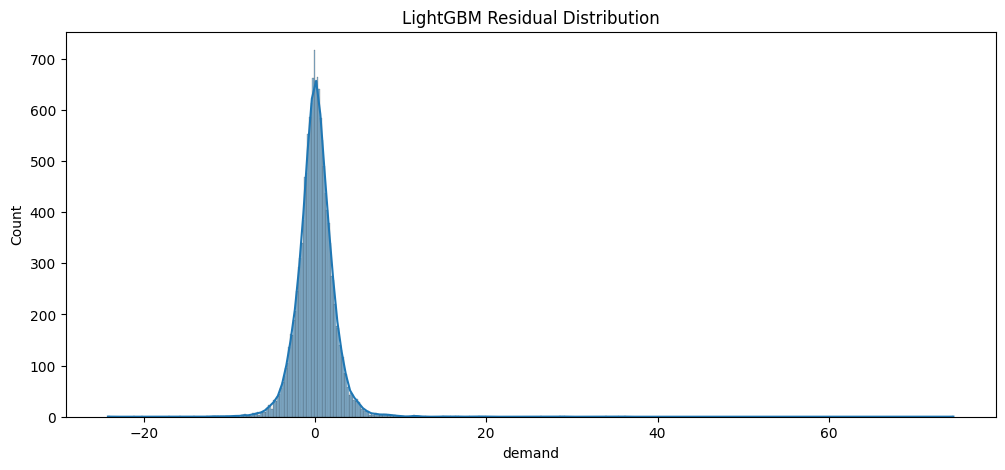

In [134]:
plt.figure(figsize=(12,5))

sns.histplot(
    lgb_residuals,
    kde=True
)

plt.title("LightGBM Residual Distribution")

plt.show()

Residual Time Plot

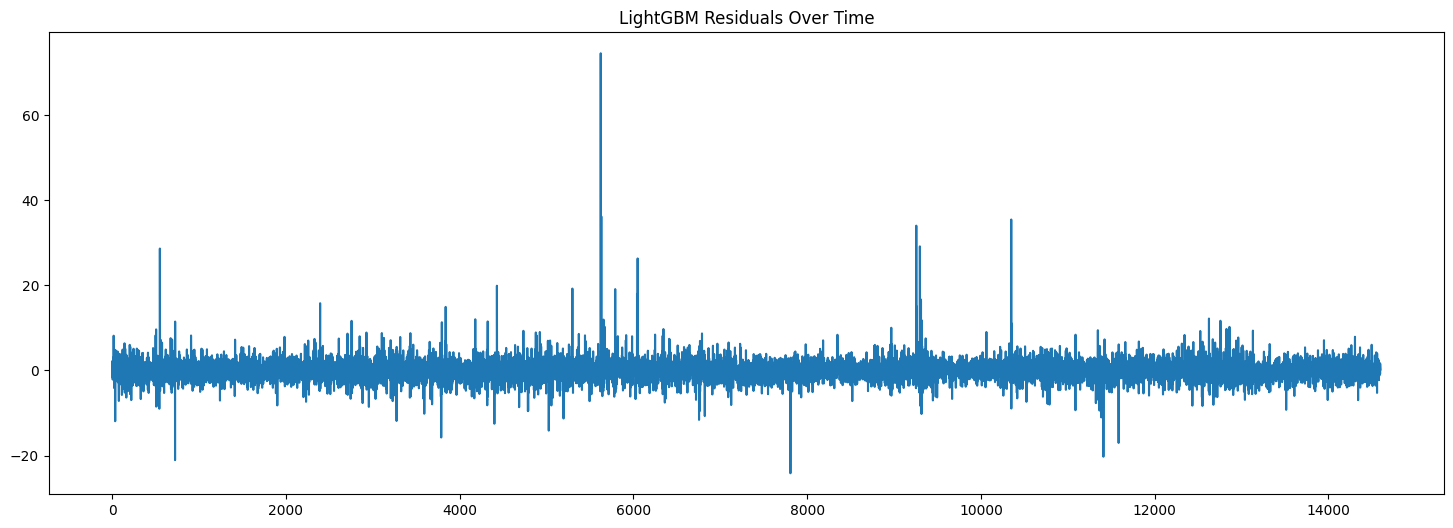

In [135]:
plt.figure(figsize=(18,6))

plt.plot(lgb_residuals.values)

plt.title("LightGBM Residuals Over Time")

plt.show()

# TimeSeriesSplit CV

Cross Validation

In [136]:
lgb_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_train)
):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]


    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        random_state=42
    )


    model.fit(X_tr, y_tr)


    val_pred = model.predict(X_val)


    mae = mean_absolute_error(
        y_val,
        val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_val,
        val_pred
    ) * 100


    lgb_cv_scores.append([
        fold + 1,
        mae,
        rmse,
        mape
    ])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5275
[LightGBM] [Info] Number of data points in the train set: 9735, number of used features: 40
[LightGBM] [Info] Start training from score 103.353261
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

CV Results

In [137]:
lgb_cv_results = pd.DataFrame(
    lgb_cv_scores,
    columns=[
        "Fold",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

lgb_cv_results

,Fold,MAE,RMSE,MAPE
0,1,2.673491,4.307607,3.411741
1,2,2.212041,3.203747,2.604249
2,3,2.117867,2.999272,2.516357
3,4,2.022501,3.010735,2.323306
4,5,1.741114,2.429912,2.569591


Average CV Metrics

In [138]:
print("Average LightGBM CV Metrics\n")

print(
    lgb_cv_results[
        ["MAE", "RMSE", "MAPE"]
    ].mean()
)

Average LightGBM CV Metrics

MAE     2.153403
RMSE    3.190255
MAPE    2.685049
dtype: float64


Ensemble Prediction

In [139]:
ensemble_pred = (
    0.6 * cat_pred +
    0.4 * lgb_pred
)

Evaluate Ensemble

In [140]:
print("Weighted Ensemble Performance\n")

ensemble_mae, ensemble_rmse, ensemble_mape = evaluate_model(
    y_test,
    ensemble_pred
)

Weighted Ensemble Performance

MAE  : 1.0560
RMSE : 1.7733
MAPE : 1.4291%


Comparison Table

In [141]:
all_results = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Rolling Mean",
        "CatBoost",
        "LightGBM",
        "Weighted Ensemble"
    ],

    "MAE": [
        naive_mae,
        rolling_mae,
        cat_mae,
        lgb_mae,
        ensemble_mae
    ],

    "RMSE": [
        naive_rmse,
        rolling_rmse,
        cat_rmse,
        lgb_rmse,
        ensemble_rmse
    ],

    "MAPE": [
        naive_mape,
        rolling_mape,
        cat_mape,
        lgb_mape,
        ensemble_mape
    ]
})

all_results

,Model,MAE,RMSE,MAPE
0,Naive Forecast,41.610822,54.376979,50.620263
1,Rolling Mean,32.714883,42.537245,43.452214
2,CatBoost,1.056456,1.820747,1.411490
3,LightGBM,1.535802,2.310731,1.912394
4,Weighted Ensemble,1.055950,1.773332,1.429075


Best RMSE Model

In [142]:
best_model = all_results.sort_values(
    by="RMSE"
).iloc[0]

best_model

,4
Model,Weighted Ensemble
MAE,1.05595
RMSE,1.773332
MAPE,1.429075


Final Plot Data

In [143]:
final_plot_df = pd.DataFrame({
    "Actual": y_test.values,
    "Ensemble_Prediction": ensemble_pred
})

final_plot_df = final_plot_df.head(300)

Ensemble Forecast Plot

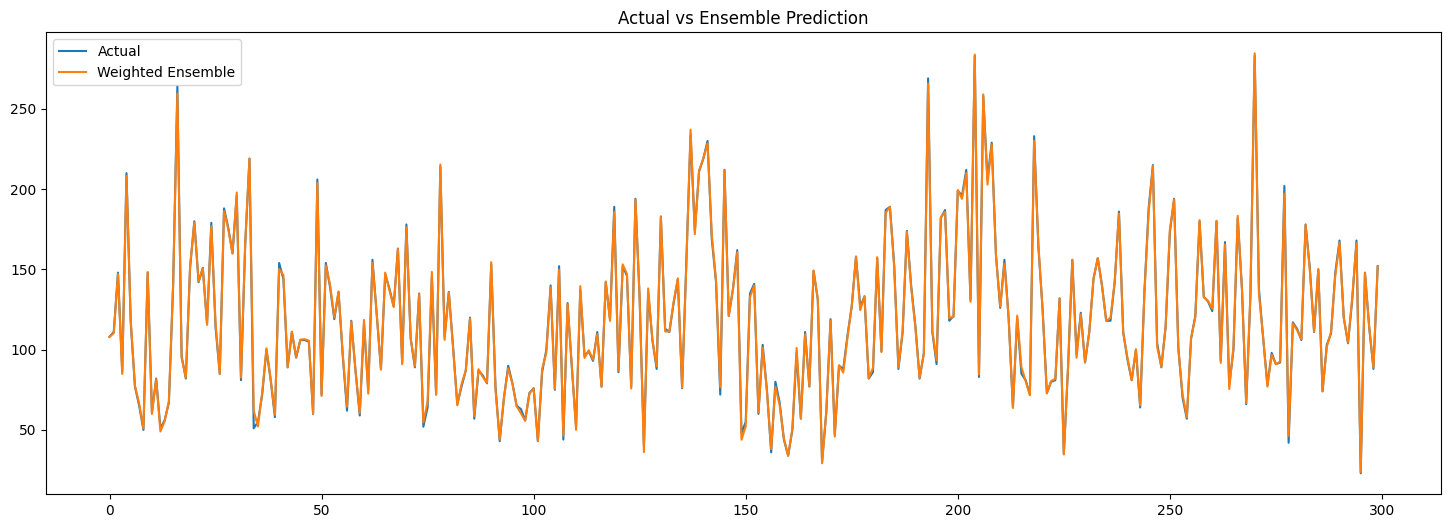

In [144]:
plt.figure(figsize=(18,6))

plt.plot(
    final_plot_df["Actual"],
    label="Actual"
)

plt.plot(
    final_plot_df["Ensemble_Prediction"],
    label="Weighted Ensemble"
)

plt.legend()

plt.title("Actual vs Ensemble Prediction")

plt.show()

Prediction DataFrame

In [145]:
prediction_df = test_df.copy()

prediction_df["catboost_prediction"] = cat_pred

prediction_df["lightgbm_prediction"] = lgb_pred

prediction_df["ensemble_prediction"] = ensemble_pred

Preview

In [146]:
prediction_df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,...,rolling_std_30,expanding_mean,demand_change_1,demand_change_7,price_diff,discounted_price,inventory_sales_ratio,catboost_prediction,lightgbm_prediction,ensemble_prediction
3043,2022-01-31,4,0,3,1,221,82,217,11.78,5,...,37.380615,119.000000,44.0,-20.0,-2.23,11.1910,2.662651,107.982656,108.151408,108.050156
3144,2022-02-01,4,0,3,1,139,115,0,12.55,5,...,36.858911,118.645161,3.0,-24.0,0.96,11.9225,1.198276,110.898455,109.247039,110.237889
3244,2022-02-02,4,0,3,1,241,135,348,11.90,15,...,35.924250,118.406250,37.0,-42.0,-1.20,10.1150,1.772059,147.955668,146.143176,147.230671
3343,2022-02-03,4,0,3,1,106,78,0,10.97,5,...,36.249598,119.303030,-62.0,-10.0,-0.68,10.4215,1.341772,85.648849,83.743294,84.886627
3444,2022-02-04,4,0,3,1,376,148,381,15.61,10,...,36.142184,118.323529,124.0,120.0,0.97,14.0490,2.523490,207.023299,209.917402,208.180940


# LOF + Z-Score Anomaly Detection System

Import Libraries

In [147]:
from sklearn.neighbors import LocalOutlierFactor

from scipy.stats import zscore

Residual Calculation

In [149]:
prediction_df["residual"] = (
    prediction_df["demand"] -
    prediction_df["ensemble_prediction"]
)

Residual Statistics

In [150]:
prediction_df["residual"].describe()

,residual
count,14600.000000
mean,0.056765
std,1.772484
min,-13.985017
25%,-0.732333
50%,0.043745
75%,0.800126
max,74.507276


# Residual Distribution

Residual Histogram

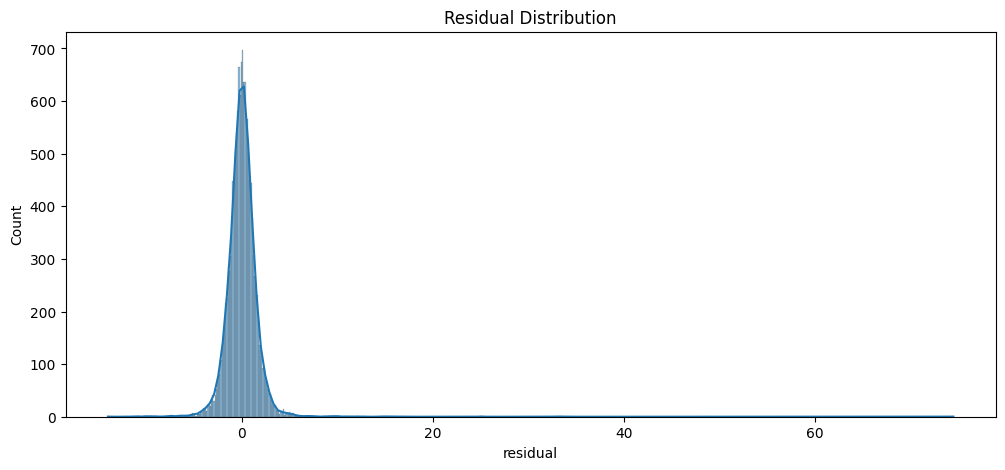

In [151]:
plt.figure(figsize=(12,5))

sns.histplot(
    prediction_df["residual"],
    kde=True
)

plt.title("Residual Distribution")

plt.show()

# LOF Anomaly Detection

Prepare Residual Data

In [152]:
lof_data = prediction_df[["residual"]]

Initialize LOF

In [153]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

Fit LOF

In [154]:
prediction_df["lof_anomaly"] = lof.fit_predict(
    lof_data
)

# Convert Labels

Binary Labels

In [155]:
prediction_df["lof_anomaly"] = (
    prediction_df["lof_anomaly"] == -1
).astype(int)

LOF Counts

In [156]:
prediction_df["lof_anomaly"].value_counts()

,count
lof_anomaly,
0,14308
1,292


# Z-Score Validation Layer

Z-Score

In [157]:
prediction_df["z_score"] = np.abs(
    zscore(
        prediction_df["residual"]
    )
)

# Threshold

Z-score Anomaly

In [158]:
prediction_df["zscore_anomaly"] = (
    prediction_df["z_score"] > 3
).astype(int)

Counts

In [159]:
prediction_df["zscore_anomaly"].value_counts()

,count
zscore_anomaly,
0,14483
1,117


# Final Combined Alert System

Final Alert

In [160]:
prediction_df["final_anomaly"] = (
    (
        prediction_df["lof_anomaly"] == 1
    ) &
    (
        prediction_df["zscore_anomaly"] == 1
    )
).astype(int)

Final Counts

In [161]:
prediction_df["final_anomaly"].value_counts()

,count
final_anomaly,
0,14532
1,68


# Extract Final Anomalies

Extract Final Anomalies

In [162]:
anomaly_df = prediction_df[
    prediction_df["final_anomaly"] == 1
]

Preview Anomalies

In [163]:
anomaly_df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,...,discounted_price,inventory_sales_ratio,catboost_prediction,lightgbm_prediction,ensemble_prediction,residual,lof_anomaly,z_score,zscore_anomaly,final_anomaly
6444,2022-03-06,4,0,3,1,26,26,0,8.00,25,...,6.000,0.962963,61.312920,62.935080,61.961784,-10.961784,1,6.216659,1,1
34143,2022-12-08,4,0,3,1,376,262,473,17.16,15,...,14.586,1.429658,292.630030,281.511272,288.182527,-10.182527,1,5.777003,1,1
53644,2023-06-21,4,0,3,1,404,112,0,11.26,10,...,10.134,3.575221,101.846392,103.507104,102.510677,-7.510677,1,4.269546,1,1
55143,2023-07-06,4,0,3,1,579,117,0,12.09,0,...,12.090,4.906780,107.353812,108.223922,107.701856,-7.701856,1,4.377410,1,1
57843,2023-08-02,4,0,3,1,17,17,0,12.35,20,...,9.880,0.944444,161.381552,155.352441,158.969908,25.030092,1,14.089938,1,1


# Time-Series Anomaly Visualization

Plot Base Data

In [164]:
plot_data = prediction_df.reset_index(drop=True)

Forecast Plot

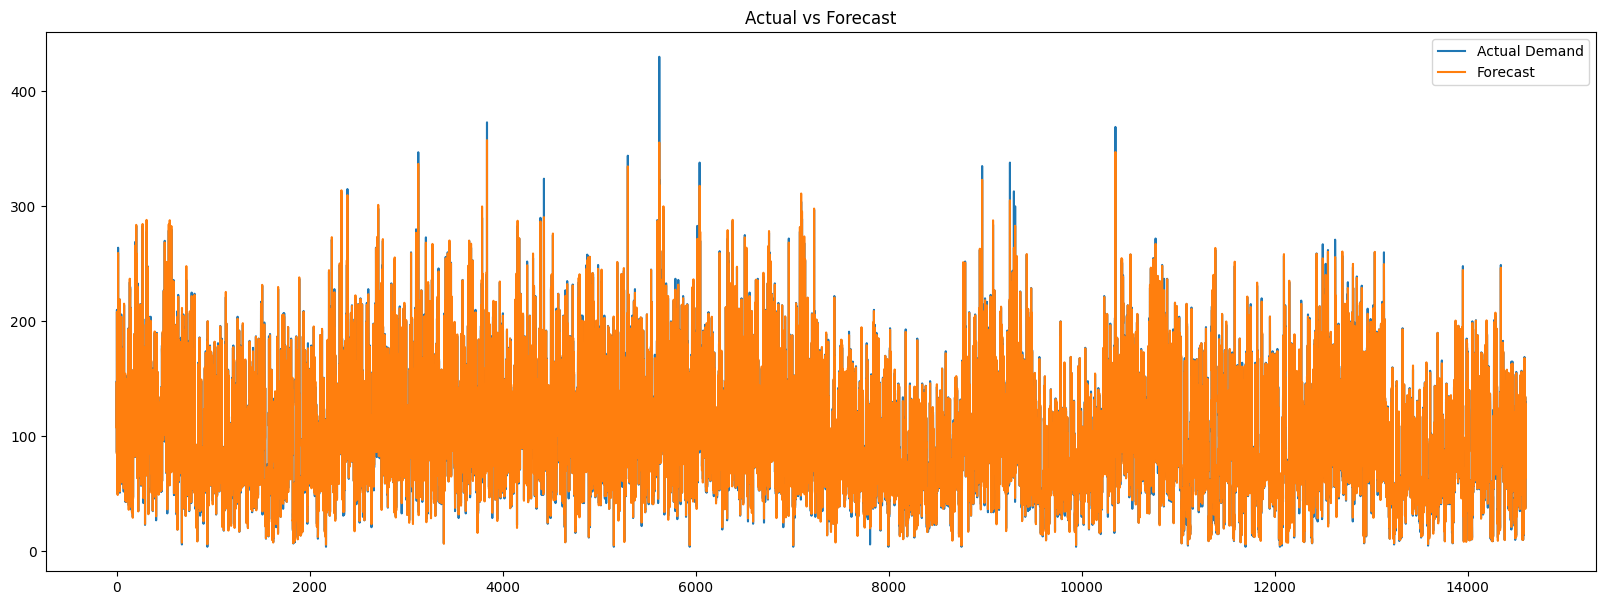

In [165]:
plt.figure(figsize=(20,7))

plt.plot(
    plot_data["demand"].values,
    label="Actual Demand"
)

plt.plot(
    plot_data["ensemble_prediction"].values,
    label="Forecast"
)

plt.legend()

plt.title("Actual vs Forecast")

plt.show()

# Highlight Anomalies

Anomaly Points

In [166]:
anomaly_points = plot_data[
    plot_data["final_anomaly"] == 1
]

Final Alert Visualization

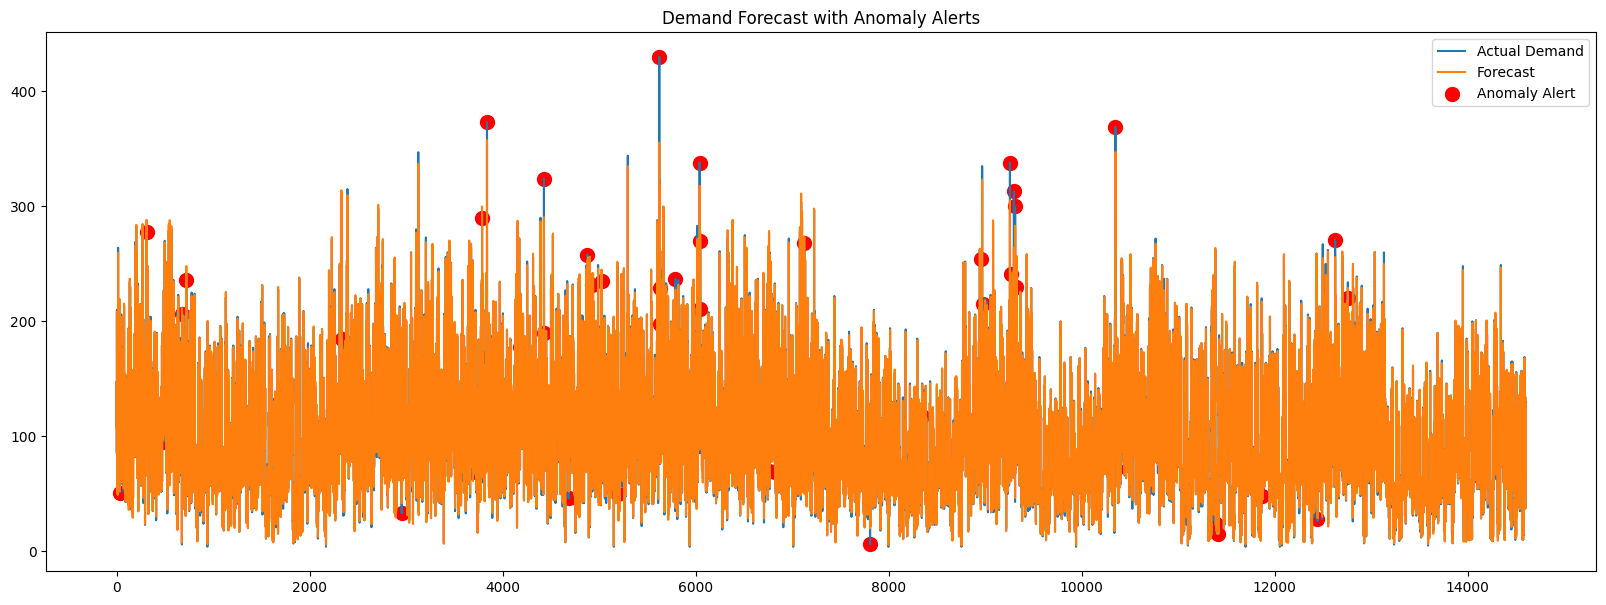

In [167]:
plt.figure(figsize=(20,7))

plt.plot(
    plot_data["demand"].values,
    label="Actual Demand"
)

plt.plot(
    plot_data["ensemble_prediction"].values,
    label="Forecast"
)

plt.scatter(
    anomaly_points.index,
    anomaly_points["demand"],
    color="red",
    s=100,
    label="Anomaly Alert"
)

plt.legend()

plt.title("Demand Forecast with Anomaly Alerts")

plt.show()

# Residual vs Threshold

Residual Plot

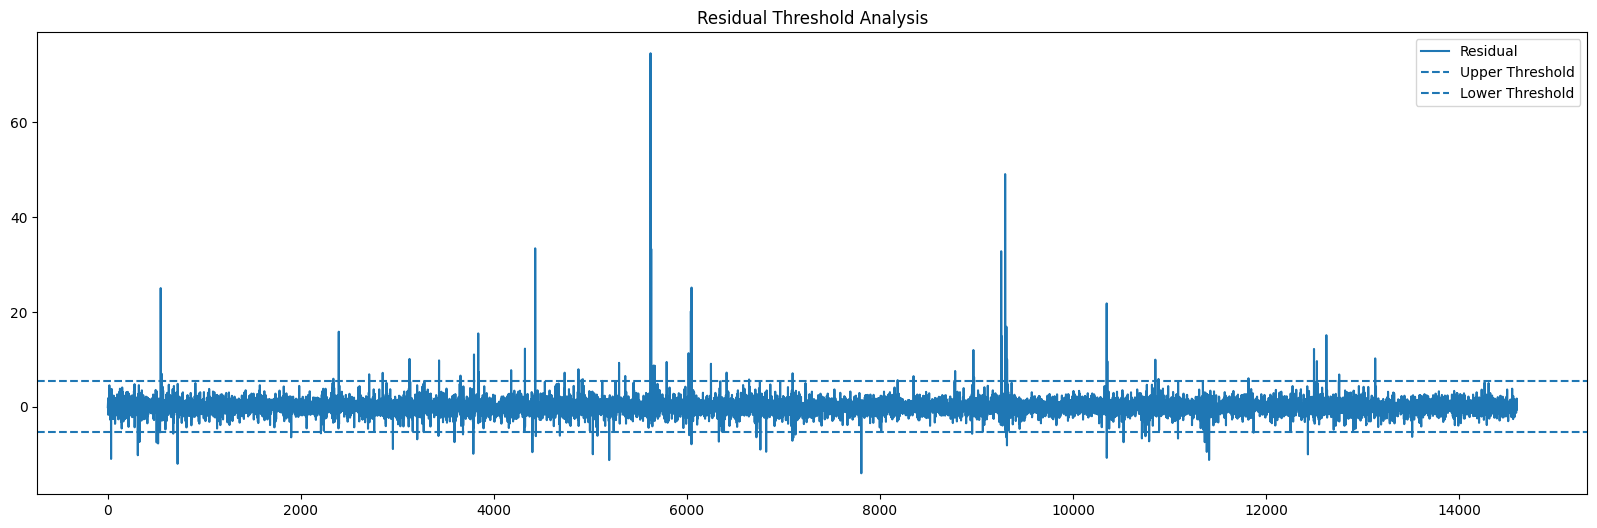

In [168]:
plt.figure(figsize=(20,6))

plt.plot(
    prediction_df["residual"].values,
    label="Residual"
)

plt.axhline(
    prediction_df["residual"].mean() +
    3 * prediction_df["residual"].std(),
    linestyle="--",
    label="Upper Threshold"
)

plt.axhline(
    prediction_df["residual"].mean() -
    3 * prediction_df["residual"].std(),
    linestyle="--",
    label="Lower Threshold"
)

plt.legend()

plt.title("Residual Threshold Analysis")

plt.show()

# Anomaly Percentage

Percentage

In [169]:
anomaly_percentage = (
    prediction_df["final_anomaly"].mean()
) * 100

print(
    f"Anomaly Percentage: {anomaly_percentage:.2f}%"
)

Anomaly Percentage: 0.47%


# Save Final Alert Dataset

Export CSV

In [170]:
prediction_df.to_csv(
    "forecast_anomaly_results.csv",
    index=False
)

# Feature Summary for Dashboard

Final Columns

In [171]:
prediction_df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'price', 'discount',
       'weather_condition', 'promotion', 'competitor_pricing', 'seasonality',
       'epidemic', 'demand', 'month', 'day_name', 'year', 'day', 'day_of_week',
       'week_of_year', 'quarter', 'is_weekend', 'is_holiday', 'month_sin',
       'month_cos', 'dow_sin', 'dow_cos', 'demand_lag_1', 'demand_lag_7',
       'demand_lag_14', 'demand_lag_30', 'rolling_mean_7', 'rolling_mean_14',
       'rolling_mean_30', 'rolling_std_7', 'rolling_std_30', 'expanding_mean',
       'demand_change_1', 'demand_change_7', 'price_diff', 'discounted_price',
       'inventory_sales_ratio', 'catboost_prediction', 'lightgbm_prediction',
       'ensemble_prediction', 'residual', 'lof_anomaly', 'z_score',
       'zscore_anomaly', 'final_anomaly'],
      dtype='object')

In [172]:
forecast_accuracy = 100 - ensemble_mape

print(
    f"Forecast Accuracy: {forecast_accuracy:.2f}%"
)

Forecast Accuracy: 98.57%


In [173]:
cat_accuracy = 100 - cat_mape

lgb_accuracy = 100 - lgb_mape

ensemble_accuracy = 100 - ensemble_mape


print(f"CatBoost Accuracy   : {cat_accuracy:.2f}%")

print(f"LightGBM Accuracy   : {lgb_accuracy:.2f}%")

print(f"Ensemble Accuracy   : {ensemble_accuracy:.2f}%")

CatBoost Accuracy   : 98.59%
LightGBM Accuracy   : 98.09%
Ensemble Accuracy   : 98.57%


In [174]:
performance_df = pd.DataFrame({
    "Model": [
        "CatBoost",
        "LightGBM",
        "Ensemble"
    ],

    "RMSE": [
        cat_rmse,
        lgb_rmse,
        ensemble_rmse
    ],

    "MAE": [
        cat_mae,
        lgb_mae,
        ensemble_mae
    ],

    "MAPE": [
        cat_mape,
        lgb_mape,
        ensemble_mape
    ],

    "Accuracy (%)": [
        100 - cat_mape,
        100 - lgb_mape,
        100 - ensemble_mape
    ]
})

performance_df

,Model,RMSE,MAE,MAPE,Accuracy (%)
0,CatBoost,1.820747,1.056456,1.411490,98.588510
1,LightGBM,2.310731,1.535802,1.912394,98.087606
2,Ensemble,1.773332,1.055950,1.429075,98.570925


In [175]:
from sklearn.metrics import r2_score

In [176]:
ensemble_r2 = r2_score(
    y_test,
    ensemble_pred
)

print(f"R² Score: {ensemble_r2:.4f}")

R² Score: 0.9987


forecast_dashboard_data.csv

In [177]:
prediction_df.to_csv(
    "forecast_dashboard_data.csv",
    index=False
)

forecast_anomaly_results.csv

In [178]:
anomaly_df.to_csv(
    "forecast_anomaly_results.csv",
    index=False
)

In [179]:
import joblib

catboost_model.pkl

In [180]:
joblib.dump(
    cat_model,
    "catboost_model.pkl"
)

['catboost_model.pkl']

lightgbm_model.pkl

In [181]:
joblib.dump(
    lgb_model,
    "lightgbm_model.pkl"
)

['lightgbm_model.pkl']

label_encoders.pkl

In [182]:
joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

['label_encoders.pkl']

Download Files From Colab

In [183]:
from google.colab import files

forecast_dashboard_data.csv

In [184]:
files.download(
    "forecast_dashboard_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

forecast_anomaly_results.csv

In [185]:
files.download(
    "forecast_anomaly_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

catboost_model.pkl

In [186]:
files.download(
    "catboost_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

lightgbm_model.pkl

In [187]:
files.download(
    "lightgbm_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

label_encoders.pkl

In [189]:
files.download(
    "label_encoders.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>